In [ ]:
# ---
# Step 0: Import required libraries
# ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
# ---
# Step 1: Load data
# ---
Medicalpremium = pd.read_csv("Medicalpremium.csv")
print(f"Dataset shape: {Medicalpremium.shape}")
print(f"\nColumns: {list(Medicalpremium.columns)}")

Dataset shape: (986, 11)

Columns: ['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants', 'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies', 'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'PremiumPrice']


In [ ]:
# ---
# Step 2: Explore data (revised)
# ---
print("\nSummary statistics:")
print(Medicalpremium.describe(include='all'))

print("\nData types:")
print(Medicalpremium.dtypes)

print("\nFirst 5 rows:")
print(Medicalpremium.head())

# Now treat NumberOfMajorSurgeries as numeric
categorical_cols = ["AnyTransplants", "Diabetes", "AnyChronicDiseases",
                    "KnownAllergies", "HistoryOfCancerInFamily", "BloodPressureProblems"]

numeric_cols = Medicalpremium.select_dtypes(include=[np.number]).columns.tolist()

# Frequency tables for categorical variables
for col in categorical_cols:
    if col in Medicalpremium.columns:
        print(f"\nValue counts for {col}:")
        print(Medicalpremium[col].value_counts())


Summary statistics:
              Age    Diabetes  BloodPressureProblems  AnyTransplants  \
count  986.000000  986.000000             986.000000      986.000000   
mean    41.745436    0.419878               0.468560        0.055781   
std     13.963371    0.493789               0.499264        0.229615   
min     18.000000    0.000000               0.000000        0.000000   
25%     30.000000    0.000000               0.000000        0.000000   
50%     42.000000    0.000000               0.000000        0.000000   
75%     53.000000    1.000000               1.000000        0.000000   
max     66.000000    1.000000               1.000000        1.000000   

       AnyChronicDiseases      Height      Weight  KnownAllergies  \
count          986.000000  986.000000  986.000000      986.000000   
mean             0.180527  168.182556   76.950304        0.215010   
std              0.384821   10.098155   14.265096        0.411038   
min              0.000000  145.000000   51.000000     

In [ ]:
# ---
# Step 4: Feature engineering (BMI)
# ---
Medicalpremium['BMI'] = Medicalpremium['Weight'] / ((Medicalpremium['Height'] / 100) ** 2)
print("\nBMI summary:")
print(Medicalpremium['BMI'].describe())


BMI summary:
count    986.000000
mean      27.460709
std        5.878671
min       15.156281
25%       23.393392
50%       27.156602
75%       30.759870
max       50.000000
Name: BMI, dtype: float64


In [ ]:
# --- Step 5a: Train-test split ---
train_data, test_data = train_test_split(Medicalpremium, test_size=0.2, random_state=42)

# --- Step 5b: Convert categorical columns ---
categorical_cols = ["AnyTransplants", "Diabetes", "AnyChronicDiseases",
                    "KnownAllergies", "HistoryOfCancerInFamily", "BloodPressureProblems"]

train_data[categorical_cols] = train_data[categorical_cols].astype('category')
test_data[categorical_cols] = test_data[categorical_cols].astype('category')

# --- Step 5c: Verify ---
print("\nTrain data types after conversion:")
print(train_data.dtypes)
print("\nTest data types after conversion:")
print(test_data.dtypes)



Train data types after conversion:
Age                           int64
Diabetes                   category
BloodPressureProblems      category
AnyTransplants             category
AnyChronicDiseases         category
Height                        int64
Weight                        int64
KnownAllergies             category
HistoryOfCancerInFamily    category
NumberOfMajorSurgeries        int64
PremiumPrice                  int64
BMI                         float64
dtype: object

Test data types after conversion:
Age                           int64
Diabetes                   category
BloodPressureProblems      category
AnyTransplants             category
AnyChronicDiseases         category
Height                        int64
Weight                        int64
KnownAllergies             category
HistoryOfCancerInFamily    category
NumberOfMajorSurgeries        int64
PremiumPrice                  int64
BMI                         float64
dtype: object


In [ ]:

# Numeric predictors + response variable 
numeric_cols_for_boxplot = ['Age', 'Weight', 'Height', 'BMI', 'PremiumPrice']


#  Calculate Outlier Counts per Variable
# ---
print("\n" + "="*40)
print("OUTLIER COUNTS PER VARIABLE")
print("="*40)

outlier_summary = []

for col in numeric_cols_for_boxplot:
    if col in train_data.columns:
        # Calculate IQR bounds
        Q1 = train_data[col].quantile(0.25)
        Q3 = train_data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Count outliers
        outliers = train_data[(train_data[col] < lower_bound) | (train_data[col] > upper_bound)]
        count = outliers.shape[0]
        
        outlier_summary.append((col, count))

# Print as a formatted table
print(f"{'Variable':<25} {'No. of Outliers'}")
print("-" * 45)
for col, count in outlier_summary:
    print(f"{col:<25} {count}")


OUTLIER COUNTS PER VARIABLE
Variable                  No. of Outliers
---------------------------------------------
Age                       0
Weight                    13
Height                    0
BMI                       18
PremiumPrice              6


In [ ]:
#check training data
print("\nData types:")
print(train_data.dtypes)



Data types:
Age                           int64
Diabetes                   category
BloodPressureProblems      category
AnyTransplants             category
AnyChronicDiseases         category
Height                        int64
Weight                        int64
KnownAllergies             category
HistoryOfCancerInFamily    category
NumberOfMajorSurgeries        int64
PremiumPrice                  int64
BMI                         float64
dtype: object


## Linear Regression with Performance Table (TRAIN + TEST)- without removing outliers

In [ ]:
#1
#Linear Regression with Performance Table (TRAIN + TEST)- without removing outliers
# ----------------------------------------
# Step 6: Prepare data (BMI only, drop Height & Weight)
# ----------------------------------------

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define predictors and response
X_train = train_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_train = train_data['PremiumPrice']

X_test = test_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_test = test_data['PremiumPrice']

# Convert categorical columns to numeric (0/1)
categorical_cols = [
    "AnyTransplants", "Diabetes", "AnyChronicDiseases",
    "KnownAllergies", "HistoryOfCancerInFamily",
    "BloodPressureProblems"
]

for col in categorical_cols:
    X_train[col] = X_train[col].astype(int)
    X_test[col] = X_test[col].astype(int)

# ----------------------------------------
# Step 7: Fit Linear Regression Model
# ----------------------------------------

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# ----------------------------------------
# Step 8: Predictions
# ----------------------------------------

y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)

# ----------------------------------------
# Step 9: Performance Metrics
# ----------------------------------------

performance = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [
        mean_squared_error(y_train, y_train_pred),
        mean_squared_error(y_test, y_test_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        np.sqrt(mean_squared_error(y_test, y_test_pred))
    ],
    "MAE": [
        mean_absolute_error(y_train, y_train_pred),
        mean_absolute_error(y_test, y_test_pred)
    ],
    "R_squared": [
        r2_score(y_train, y_train_pred),
        r2_score(y_test, y_test_pred)
    ]
})

print(performance)

#Coefficient Table (for interpretation)
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lin_reg.coef_
}).sort_values(by="Coefficient", ascending=False)

print(coefficients)


    Dataset           MSE         RMSE          MAE  R_squared
0  Training  1.468784e+07  3832.472242  2716.706343   0.614109
1   Testing  1.245864e+07  3529.679563  2629.648554   0.707837
                   Feature  Coefficient
3           AnyTransplants  7410.506399
4       AnyChronicDiseases  2560.183628
6  HistoryOfCancerInFamily  2128.597664
0                      Age   325.528147
5           KnownAllergies   167.605717
8                      BMI   141.854419
2    BloodPressureProblems    83.293941
1                 Diabetes  -365.234726
7   NumberOfMajorSurgeries  -659.549164


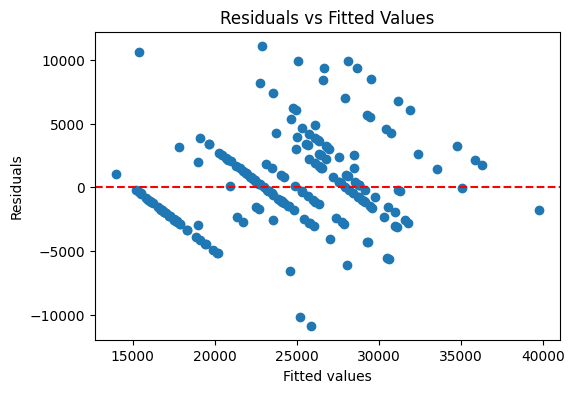

In [ ]:
#Plot 1: Residuals vs Fitted Values
#Purpose
#Checks:
#Linearity
#Homoscedasticity
#Interpretation
#Good:
#Random scatter around 0
#No curve
#No funnel shape
#Bad:
#U-shape → non-linearity
#Funnel → heteroscedasticity



residuals = y_test - y_test_pred

plt.figure(figsize=(6,4))
plt.scatter(y_test_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


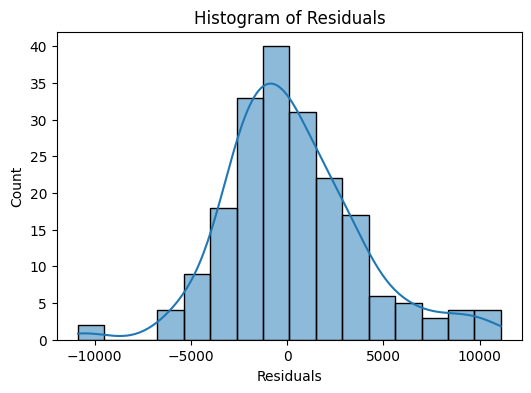

In [ ]:
#Plot 2: Histogram of Residuals
#Purpose
#Checks:
#Normality of errors
#Approximately bell-shaped → OK

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.xlabel("Residuals")
plt.title("Histogram of Residuals")
plt.show()


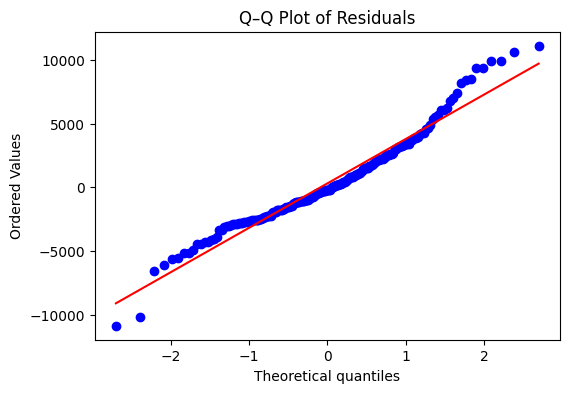

In [ ]:
#Plot 3: Q–Q Plot of Residuals
#Purpose
#Formal visual check for normality
#Interpretation
# Points lie close to straight line → normality
# Strong S-shape → violation


import scipy.stats as stats

plt.figure(figsize=(6,4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q–Q Plot of Residuals")
plt.show()


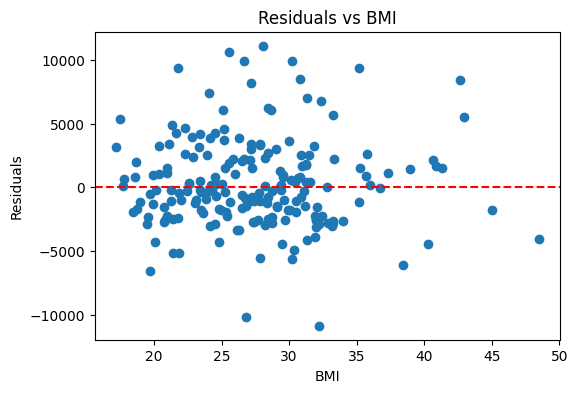

In [ ]:
#Plot 4: Residuals vs BMI (optional but useful)
#Purpose
#Checks:
#Whether BMI relationship is linear
#Whether transformation is neededLinear relationship (good)

#Residuals scatter randomly around 0
#No visible curve (U-shape, inverted U, etc.)
#Spread is roughly constant across BMI range

plt.figure(figsize=(6,4))
plt.scatter(X_test['BMI'], residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("BMI")
plt.ylabel("Residuals")
plt.title("Residuals vs BMI")
plt.show()


## Linear Regression with Performance Table (TRAIN + TEST)- removing outliers

In [ ]:
#Step 1: Identify Outliers in Training Data

numeric_cols_for_outlier = ['Age', 'BMI', 'NumberOfMajorSurgeries', 'PremiumPrice']

# Create a mask for all rows that are NOT outliers
mask = pd.Series(True, index=train_data.index)

for col in numeric_cols_for_outlier:
    Q1 = train_data[col].quantile(0.25)
    Q3 = train_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask &= (train_data[col] >= lower) & (train_data[col] <= upper)

# Remove outliers
train_clean = train_data[mask].copy()
print(f"Original training rows: {train_data.shape[0]}")
print(f"After removing outliers: {train_clean.shape[0]}")


Original training rows: 788
After removing outliers: 749


In [ ]:
#Step 2: Prepare Features (Same as Before)

X_train_clean = train_clean.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_train_clean = train_clean['PremiumPrice']

X_test_model = test_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_test_model = test_data['PremiumPrice']

# Convert categorical columns back to 0/1
categorical_cols = [
    "AnyTransplants", "Diabetes", "AnyChronicDiseases",
    "KnownAllergies", "HistoryOfCancerInFamily",
    "BloodPressureProblems"
]

for col in categorical_cols:
    X_train_clean[col] = X_train_clean[col].astype(int)
    X_test_model[col] = X_test_model[col].astype(int)


#Step 3: Fit Linear Regression (Without Outliers)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Fit model
lin_reg_clean = LinearRegression()
lin_reg_clean.fit(X_train_clean, y_train_clean)

# Predictions
y_train_pred_clean = lin_reg_clean.predict(X_train_clean)
y_test_pred_clean = lin_reg_clean.predict(X_test_model)

# Performance metrics table
performance_clean = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [
        mean_squared_error(y_train_clean, y_train_pred_clean),
        mean_squared_error(y_test_model, y_test_pred_clean)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train_clean, y_train_pred_clean)),
        np.sqrt(mean_squared_error(y_test_model, y_test_pred_clean))
    ],
    "MAE": [
        mean_absolute_error(y_train_clean, y_train_pred_clean),
        mean_absolute_error(y_test_model, y_test_pred_clean)
    ],
    "R_squared": [
        r2_score(y_train_clean, y_train_pred_clean),
        r2_score(y_test_model, y_test_pred_clean)
    ]
})

print(performance_clean)



    Dataset           MSE         RMSE          MAE  R_squared
0  Training  1.184972e+07  3442.341978  2556.761265   0.675921
1   Testing  1.241953e+07  3524.134844  2601.173511   0.708754


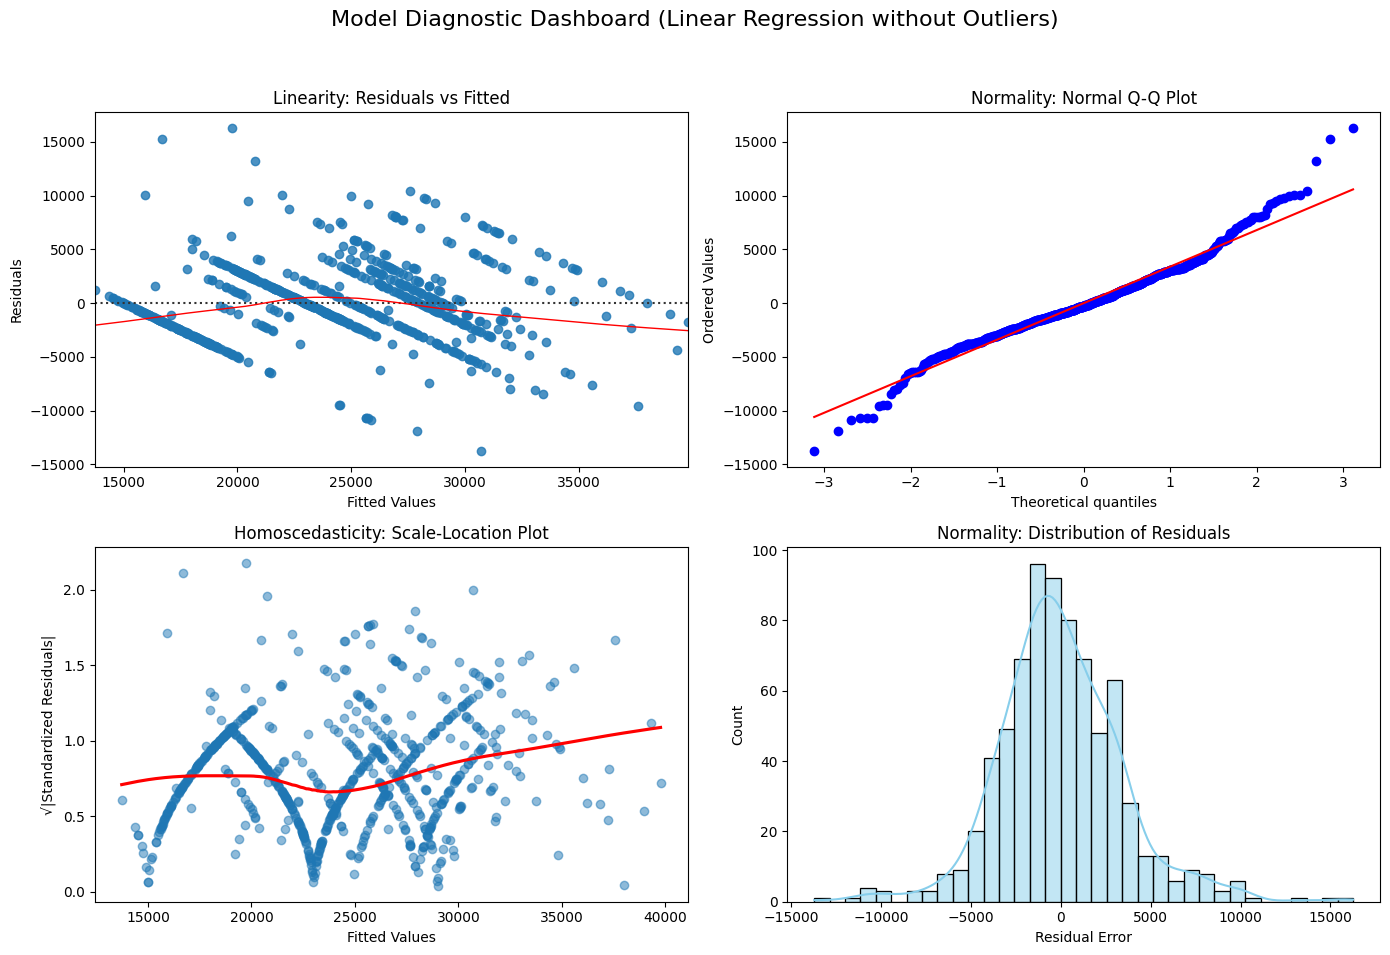

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import numpy as np

# Set up a 2x2 grid for diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Diagnostic Dashboard (Linear Regression without Outliers)', fontsize=16)

# 1. Linearity Assumption
# Residuals vs Fitted (Checks Linearity)
sns.residplot(x=y_train_pred_clean, y=y_train_clean - y_train_pred_clean, lowess=True, 
              ax=axes[0, 0], line_kws={'color': 'red', 'lw': 1})
axes[0, 0].set_title('Linearity: Residuals vs Fitted')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')

# 2. Normality Assumption (Part A)
# Normal Q-Q Plot (Checks Normality of Residuals)
residuals = y_train_clean - y_train_pred_clean
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Normality: Normal Q-Q Plot')

# 3. Homoscedasticity Assumption
# Scale-Location Plot (Checks Homoscedasticity/Equal Variance)
standardized_residuals = (residuals - np.mean(residuals)) / np.std(residuals)
axes[1, 0].scatter(y_train_pred_clean, np.sqrt(np.abs(standardized_residuals)), alpha=0.5)
sns.regplot(x=y_train_pred_clean, y=np.sqrt(np.abs(standardized_residuals)), 
            scatter=False, ci=None, lowess=True, ax=axes[1, 0], line_kws={'color': 'red'})
axes[1, 0].set_title('Homoscedasticity: Scale-Location Plot')
axes[1, 0].set_xlabel('Fitted Values')
axes[1, 0].set_ylabel('√|Standardized Residuals|')

# 4. Normality Assumption (Part B)
# Distribution of Residuals (Provides a visual check of error symmetry)
sns.histplot(residuals, kde=True, ax=axes[1, 1], color='skyblue')
axes[1, 1].set_title('Normality: Distribution of Residuals')
axes[1, 1].set_xlabel('Residual Error')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

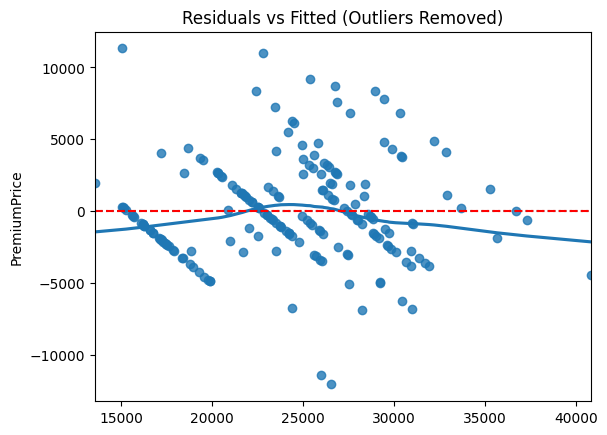

In [ ]:
#Step 5: Check Residuals Again
residuals_clean = y_test_model - y_test_pred_clean
sns.residplot(x=y_test_pred_clean, y=residuals_clean, lowess=True)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted (Outliers Removed)")
plt.show()


In [ ]:
# ==========================================================
# GRNN-TYPE MODEL (Kernel Ridge, RBF) - WITH OUTLIERS (TUNED)
# ==========================================================

from sklearn.model_selection import GridSearchCV
from sklearn.kernel_ridge import KernelRidge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# --------------------------
# Step 1: Prepare features
# --------------------------
X_train_grnn = train_data.drop(columns=['PremiumPrice', 'Height', 'Weight']) 
y_train_grnn = train_data['PremiumPrice'].values 

X_test_grnn = test_data.drop(columns=['PremiumPrice', 'Height', 'Weight']) 
y_test_grnn = test_data['PremiumPrice'].values 

categorical_cols = [
    "AnyTransplants", "Diabetes", "AnyChronicDiseases",
    "KnownAllergies", "HistoryOfCancerInFamily",
    "BloodPressureProblems"
] 

for col in categorical_cols:
    X_train_grnn[col] = X_train_grnn[col].astype(int) 
    X_test_grnn[col] = X_test_grnn[col].astype(int) 

# --------------------------
# Step 2: Scaling
# --------------------------
scaler = StandardScaler()
X_train_grnn_scaled = scaler.fit_transform(X_train_grnn) 
X_test_grnn_scaled = scaler.transform(X_test_grnn) 

# --------------------------
# Step 3: Train model with Hyperparameter Tuning
# --------------------------
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'gamma': [0.001, 0.01, 0.1, 1, 10]
}

grid_krr = GridSearchCV(KernelRidge(kernel='rbf'), param_grid, cv=5, scoring='r2')
grid_krr.fit(X_train_grnn_scaled, y_train_grnn)

# Best estimator replaces the manual krr
krr = grid_krr.best_estimator_
print(f"Best Parameters (With Outliers): {grid_krr.best_params_}")

# --------------------------
# Step 4: Predictions
# --------------------------
y_train_pred = krr.predict(X_train_grnn_scaled) 
y_test_pred = krr.predict(X_test_grnn_scaled) 

# --------------------------
# Step 5: Performance table
# --------------------------
performance_krr = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [
        mean_squared_error(y_train_grnn, y_train_pred),
        mean_squared_error(y_test_grnn, y_test_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train_grnn, y_train_pred)),
        np.sqrt(mean_squared_error(y_test_grnn, y_test_pred))
    ],
    "MAE": [
        mean_absolute_error(y_train_grnn, y_train_pred),
        mean_absolute_error(y_test_grnn, y_test_pred)
    ],
    "R_squared": [
        r2_score(y_train_grnn, y_train_pred),
        r2_score(y_test_grnn, y_test_pred)
    ]
})

print("\nGRNN-type (Kernel Ridge) Performance - WITH Outliers (Tuned)")
print(performance_krr)

Best Parameters (With Outliers): {'alpha': 0.01, 'gamma': 0.01}

GRNN-type (Kernel Ridge) Performance - WITH Outliers (Tuned)
    Dataset           MSE         RMSE          MAE  R_squared
0  Training  1.007262e+07  3173.739307  2122.764941   0.735364
1   Testing  1.030999e+07  3210.917124  2334.288182   0.758224


In [ ]:
# ==========================================================
# GRNN-TYPE MODEL (Kernel Ridge, RBF) - WITHOUT OUTLIERS (TUNED)
# ==========================================================

# --------------------------
# Step 1: Prepare features
# --------------------------
X_train_grnn_clean = train_clean.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_train_grnn_clean = train_clean['PremiumPrice'].values

X_test_grnn_clean = test_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_test_grnn_clean = test_data['PremiumPrice'].values 
for col in categorical_cols:
    X_train_grnn_clean[col] = X_train_grnn_clean[col].astype(int) 
    X_test_grnn_clean[col] = X_test_grnn_clean[col].astype(int) 

# --------------------------
# Step 2: Scaling
# --------------------------
scaler_clean = StandardScaler()
X_train_grnn_clean_scaled = scaler_clean.fit_transform(X_train_grnn_clean) 
X_test_grnn_clean_scaled = scaler_clean.transform(X_test_grnn_clean) 

# --------------------------
# Step 3: Train model with Hyperparameter Tuning
# --------------------------
grid_krr_clean = GridSearchCV(KernelRidge(kernel='rbf'), param_grid, cv=10, scoring='r2')
grid_krr_clean.fit(X_train_grnn_clean_scaled, y_train_grnn_clean)

# Best estimator replaces krr_clean
krr_clean = grid_krr_clean.best_estimator_
print(f"Best Parameters (Without Outliers): {grid_krr_clean.best_params_}")

# --------------------------
# Step 4: Predictions
# --------------------------
y_train_pred_clean = krr_clean.predict(X_train_grnn_clean_scaled) 
y_test_pred_clean = krr_clean.predict(X_test_grnn_clean_scaled) 

# --------------------------
# Step 5: Performance table
# --------------------------
performance_krr_clean = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [
        mean_squared_error(y_train_grnn_clean, y_train_pred_clean),
        mean_squared_error(y_test_grnn_clean, y_test_pred_clean)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train_grnn_clean, y_train_pred_clean)),
        np.sqrt(mean_squared_error(y_test_grnn_clean, y_test_pred_clean))
    ],
    "MAE": [
        mean_absolute_error(y_train_grnn_clean, y_train_pred_clean),
        mean_absolute_error(y_test_grnn_clean, y_test_pred_clean)
    ],
    "R_squared": [
        r2_score(y_train_grnn_clean, y_train_pred_clean),
        r2_score(y_test_grnn_clean, y_test_pred_clean)
    ]
}) 

print("\nGRNN-type (Kernel Ridge) Performance - WITHOUT Outliers (Tuned)")
print(performance_krr_clean)

# Extract the best parameters from your GridSearchCV
best_params = grid_krr_clean.best_params_

print(f"Applied: Tried with Gaussian Kernel function as the radial basis function")
print(f"Optimal Gamma (Spread) = {best_params['gamma']}")
print(f"Optimal Alpha (Regularization) = {best_params['alpha']}")

Best Parameters (Without Outliers): {'alpha': 0.1, 'gamma': 0.01}

GRNN-type (Kernel Ridge) Performance - WITHOUT Outliers (Tuned)
    Dataset           MSE         RMSE          MAE  R_squared
0  Training  8.918744e+06  2986.426702  2164.301928   0.756081
1   Testing  1.027634e+07  3205.673285  2302.902912   0.759013
Applied: Tried with Gaussian Kernel function as the radial basis function
Optimal Gamma (Spread) = 0.01
Optimal Alpha (Regularization) = 0.1


In [ ]:
# ==========================================================
# FFNN (MLPRegressor) - WITH OUTLIERS
# ==========================================================

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# --------------------------
# Step 1: Prepare features
# --------------------------

X_train_ffnn = train_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_train_ffnn = train_data['PremiumPrice'].values

X_test_ffnn = test_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_test_ffnn = test_data['PremiumPrice'].values

categorical_cols = [
    "AnyTransplants", "Diabetes", "AnyChronicDiseases",
    "KnownAllergies", "HistoryOfCancerInFamily",
    "BloodPressureProblems"
]

for col in categorical_cols:
    X_train_ffnn[col] = X_train_ffnn[col].astype(int)
    X_test_ffnn[col] = X_test_ffnn[col].astype(int)

# --------------------------
# Step 2: Scaling (MANDATORY)
# --------------------------

scaler_ffnn = StandardScaler()
X_train_ffnn_scaled = scaler_ffnn.fit_transform(X_train_ffnn)
X_test_ffnn_scaled = scaler_ffnn.transform(X_test_ffnn)

# --------------------------
# Step 3: Train FFNN
# --------------------------

ffnn = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=5000,      # Increased to help with the ConvergenceWarning 
    early_stopping=True, # <--- Add this here
    validation_fraction=0.1, # 10% of training data used for the stopping chec,
    random_state=42
)

ffnn.fit(X_train_ffnn_scaled, y_train_ffnn)

# --------------------------
# Step 4: Predictions
# --------------------------

y_train_pred_ffnn = ffnn.predict(X_train_ffnn_scaled)
y_test_pred_ffnn = ffnn.predict(X_test_ffnn_scaled)

# --------------------------
# Step 5: Performance table
# --------------------------

performance_ffnn = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [
        mean_squared_error(y_train_ffnn, y_train_pred_ffnn),
        mean_squared_error(y_test_ffnn, y_test_pred_ffnn)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train_ffnn, y_train_pred_ffnn)),
        np.sqrt(mean_squared_error(y_test_ffnn, y_test_pred_ffnn))
    ],
    "MAE": [
        mean_absolute_error(y_train_ffnn, y_train_pred_ffnn),
        mean_absolute_error(y_test_ffnn, y_test_pred_ffnn)
    ],
    "R_squared": [
        r2_score(y_train_ffnn, y_train_pred_ffnn),
        r2_score(y_test_ffnn, y_test_pred_ffnn)
    ]
})

print("\nFFNN Performance - WITH Outliers")
print(performance_ffnn)



FFNN Performance - WITH Outliers
    Dataset           MSE         RMSE          MAE  R_squared
0  Training  1.421140e+07  3769.801108  2705.716390   0.626626
1   Testing  1.268578e+07  3561.709884  2671.721571   0.702511


In [ ]:
# ==========================================================
# FFNN (MLPRegressor) - WITHOUT OUTLIERS
# ==========================================================

X_train_ffnn_clean = train_clean.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_train_ffnn_clean = train_clean['PremiumPrice'].values

X_test_ffnn_clean = test_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_test_ffnn_clean = test_data['PremiumPrice'].values

for col in categorical_cols:
    X_train_ffnn_clean[col] = X_train_ffnn_clean[col].astype(int)
    X_test_ffnn_clean[col] = X_test_ffnn_clean[col].astype(int)

scaler_ffnn_clean = StandardScaler()
X_train_ffnn_clean_scaled = scaler_ffnn_clean.fit_transform(X_train_ffnn_clean)
X_test_ffnn_clean_scaled = scaler_ffnn_clean.transform(X_test_ffnn_clean)

ffnn_clean = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=5000,      # Increased to help with the ConvergenceWarning 
    early_stopping=True, # <--- Add this here
    validation_fraction=0.1, # 10% of training data used for the stopping chec,
    random_state=42
)

ffnn_clean.fit(X_train_ffnn_clean_scaled, y_train_ffnn_clean)

y_train_pred_ffnn_clean = ffnn_clean.predict(X_train_ffnn_clean_scaled)
y_test_pred_ffnn_clean = ffnn_clean.predict(X_test_ffnn_clean_scaled)

performance_ffnn_clean = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [
        mean_squared_error(y_train_ffnn_clean, y_train_pred_ffnn_clean),
        mean_squared_error(y_test_ffnn_clean, y_test_pred_ffnn_clean)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train_ffnn_clean, y_train_pred_ffnn_clean)),
        np.sqrt(mean_squared_error(y_test_ffnn_clean, y_test_pred_ffnn_clean))
    ],
    "MAE": [
        mean_absolute_error(y_train_ffnn_clean, y_train_pred_ffnn_clean),
        mean_absolute_error(y_test_ffnn_clean, y_test_pred_ffnn_clean)
    ],
    "R_squared": [
        r2_score(y_train_ffnn_clean, y_train_pred_ffnn_clean),
        r2_score(y_test_ffnn_clean, y_test_pred_ffnn_clean)
    ]
})

print("\nFFNN Performance - WITHOUT Outliers")
print(performance_ffnn_clean)



FFNN Performance - WITHOUT Outliers
    Dataset           MSE         RMSE          MAE  R_squared
0  Training  1.363264e+07  3692.239954  2827.204704   0.627160
1   Testing  1.516600e+07  3894.355358  2877.500726   0.644348


In [ ]:
# ==========================================================
# KNN REGRESSION - FULLY TUNED (WITH OUTLIERS)
# ==========================================================

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# --- Step 1: Prepare features ---
X_train_knn = train_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_train_knn = train_data['PremiumPrice'].values
X_test_knn = test_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_test_knn = test_data['PremiumPrice'].values

categorical_cols = ["AnyTransplants", "Diabetes", "AnyChronicDiseases", "KnownAllergies", "HistoryOfCancerInFamily", "BloodPressureProblems"]
for col in categorical_cols:
    X_train_knn[col] = X_train_knn[col].astype(int)
    X_test_knn[col] = X_test_knn[col].astype(int)

# --- Step 2: Scaling (CRITICAL for KNN) ---
scaler_knn = StandardScaler()
X_train_knn_scaled = scaler_knn.fit_transform(X_train_knn)
X_test_knn_scaled = scaler_knn.transform(X_test_knn)

# --- Step 3: Hyperparameter Tuning with Grid Search ---
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'uniform'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(KNeighborsRegressor(), param_grid_knn, cv=5, scoring='r2', n_jobs=-1)
grid_knn.fit(X_train_knn_scaled, y_train_knn)

knn_tuned = grid_knn.best_estimator_
print(f"Best Parameters (With Outliers): {grid_knn.best_params_}")

# --- Step 4: Predictions ---
y_train_pred_knn = knn_tuned.predict(X_train_knn_scaled)
y_test_pred_knn = knn_tuned.predict(X_test_knn_scaled)

# --- Step 5: Performance table ---
performance_knn = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [mean_squared_error(y_train_knn, y_train_pred_knn), mean_squared_error(y_test_knn, y_test_pred_knn)],
    "RMSE": [np.sqrt(mean_squared_error(y_train_knn, y_train_pred_knn)), np.sqrt(mean_squared_error(y_test_knn, y_test_pred_knn))],
    "MAE": [mean_absolute_error(y_train_knn, y_train_pred_knn), mean_absolute_error(y_test_knn, y_test_pred_knn)],
    "R_squared": [r2_score(y_train_knn, y_train_pred_knn), r2_score(y_test_knn, y_test_pred_knn)]
})

print("\nKNN Performance - WITH Outliers (Fully Tuned)")
print(performance_knn)



Best Parameters (With Outliers): {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}

KNN Performance - WITH Outliers (Fully Tuned)
    Dataset           MSE         RMSE          MAE  R_squared
0  Training  1.248519e+07  3533.438262  2261.421320   0.671979
1   Testing  1.648969e+07  4060.750281  2772.727273   0.613306


In [ ]:
# ==========================================================
# KNN REGRESSION - FULLY TUNED (WITHOUT OUTLIERS)
# ==========================================================

# --- Step 1: Prepare features ---
X_train_knn_clean = train_clean.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_train_knn_clean = train_clean['PremiumPrice'].values
X_test_knn_clean = test_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_test_knn_clean = test_data['PremiumPrice'].values

for col in categorical_cols:
    X_train_knn_clean[col] = X_train_knn_clean[col].astype(int)
    X_test_knn_clean[col] = X_test_knn_clean[col].astype(int)

# --- Step 2: Scaling ---
scaler_knn_clean = StandardScaler()
X_train_knn_clean_scaled = scaler_knn_clean.fit_transform(X_train_knn_clean)
X_test_knn_clean_scaled = scaler_knn_clean.transform(X_test_knn_clean)

# --- Step 3: Hyperparameter Tuning with Grid Search ---
grid_knn_clean = GridSearchCV(KNeighborsRegressor(), param_grid_knn, cv=5, scoring='r2', n_jobs=-1)
grid_knn_clean.fit(X_train_knn_clean_scaled, y_train_knn_clean)

knn_clean_tuned = grid_knn_clean.best_estimator_
print(f"Best Parameters (Without Outliers): {grid_knn_clean.best_params_}")

# --- Step 4: Predictions ---
y_train_pred_knn_clean = knn_clean_tuned.predict(X_train_knn_clean_scaled)
y_test_pred_knn_clean = knn_clean_tuned.predict(X_test_knn_clean_scaled)

# --- Step 5: Performance table ---
performance_knn_clean = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [mean_squared_error(y_train_knn_clean, y_train_pred_knn_clean), mean_squared_error(y_test_knn_clean, y_test_pred_knn_clean)],
    "RMSE": [np.sqrt(mean_squared_error(y_train_knn_clean, y_train_pred_knn_clean)), np.sqrt(mean_squared_error(y_test_knn_clean, y_test_pred_knn_clean))],
    "MAE": [mean_absolute_error(y_train_knn_clean, y_train_pred_knn_clean), mean_absolute_error(y_test_knn_clean, y_test_pred_knn_clean)],
    "R_squared": [r2_score(y_train_knn_clean, y_train_pred_knn_clean), r2_score(y_test_knn_clean, y_test_pred_knn_clean)]
})

print("\nKNN Performance - WITHOUT Outliers (Fully Tuned)")
print(performance_knn_clean)

Best Parameters (Without Outliers): {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}

KNN Performance - WITHOUT Outliers (Fully Tuned)
    Dataset           MSE         RMSE          MAE  R_squared
0  Training  9.958451e+06  3155.701391  1971.695594   0.727646
1   Testing  1.638606e+07  4047.969936  2532.323232   0.615737


In [ ]:
# ==========================================================
# SVR - FULLY TUNED (WITH OUTLIERS)
# ==========================================================

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# --- Step 1: Scaling (Crucial for SVR) ---
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# --- Step 2: Hyperparameter Tuning ---
param_grid_svr = {
    'C': [1, 10, 100, 1000],
    'epsilon': [0.01, 0.1, 0.2],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

grid_svr = GridSearchCV(SVR(kernel='rbf'), param_grid_svr, cv=5, scoring='r2', n_jobs=-1)
grid_svr.fit(X_train_s, y_train_s)

svr_tuned = grid_svr.best_estimator_
print(f"Best Parameters (With Outliers): {grid_svr.best_params_}")

# --- Step 3: Predictions & Inverse Scaling ---
y_train_pred_s = svr_tuned.predict(X_train_s)
y_test_pred_s = svr_tuned.predict(X_test_s)

# Transform back to original price scale
y_train_pred = scaler_y.inverse_transform(y_train_pred_s.reshape(-1, 1)).ravel()
y_test_pred = scaler_y.inverse_transform(y_test_pred_s.reshape(-1, 1)).ravel()

# --- Step 4: Performance Table ---
performance_svr = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "RMSE": [np.sqrt(mean_squared_error(y_train, y_train_pred)), np.sqrt(mean_squared_error(y_test, y_test_pred))],
    "MAE": [mean_absolute_error(y_train, y_train_pred), mean_absolute_error(y_test, y_test_pred)],
    "R_squared": [r2_score(y_train, y_train_pred), r2_score(y_test, y_test_pred)]
})

print("\nSVR Performance - WITH Outliers (Fully Tuned)")
print(performance_svr)

Best Parameters (With Outliers): {'C': 100, 'epsilon': 0.01, 'gamma': 0.01}

SVR Performance - WITH Outliers (Fully Tuned)
    Dataset         RMSE          MAE  R_squared
0  Training  3250.517705  1965.706011   0.722405
1   Testing  3265.287030  2282.146912   0.749967


In [ ]:
# ==========================================================
# SVR - FULLY TUNED (WITHOUT OUTLIERS)
# ==========================================================

# --- Step 1: Scaling ---
scaler_X_no = StandardScaler()
scaler_y_no = StandardScaler()

X_train_clean_s = scaler_X_no.fit_transform(X_train_clean)
X_test_s_no = scaler_X_no.transform(X_test)
y_train_clean_s = scaler_y_no.fit_transform(y_train_clean.values.reshape(-1, 1)).ravel()

# --- Step 2: Hyperparameter Tuning ---
grid_svr_no = GridSearchCV(SVR(kernel='rbf'), param_grid_svr, cv=5, scoring='r2', n_jobs=-1)
grid_svr_no.fit(X_train_clean_s, y_train_clean_s)

svr_no_tuned = grid_svr_no.best_estimator_
print(f"Best Parameters (Without Outliers): {grid_svr_no.best_params_}")

# --- Step 3: Predictions & Inverse Scaling ---
y_train_pred_no_s = svr_no_tuned.predict(X_train_clean_s)
y_test_pred_no_s = svr_no_tuned.predict(X_test_s_no)

y_train_pred_no = scaler_y_no.inverse_transform(y_train_pred_no_s.reshape(-1, 1)).ravel()
y_test_pred_no = scaler_y_no.inverse_transform(y_test_pred_no_s.reshape(-1, 1)).ravel()

# --- Step 4: Performance Table ---
performance_svr_no = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "RMSE": [np.sqrt(mean_squared_error(y_train_clean, y_train_pred_no)), np.sqrt(mean_squared_error(y_test, y_test_pred_no))],
    "MAE": [mean_absolute_error(y_train_clean, y_train_pred_no), mean_absolute_error(y_test, y_test_pred_no)],
    "R_squared": [r2_score(y_train_clean, y_train_pred_no), r2_score(y_test, y_test_pred_no)]
})

print("\nSVR Performance - WITHOUT Outliers (Fully Tuned)")
print(performance_svr_no)

Best Parameters (Without Outliers): {'C': 10, 'epsilon': 0.2, 'gamma': 0.01}

SVR Performance - WITHOUT Outliers (Fully Tuned)
    Dataset         RMSE          MAE  R_squared
0  Training  3034.752670  2096.328946   0.748123
1   Testing  3326.424509  2297.559611   0.740517


Best Parameters (With Outliers): {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}

Random Forest Performance - WITH Outliers (Fully Tuned, No Scaling)
    Dataset           MSE         RMSE          MAE  R_squared
0  Training  4.827995e+06  2197.269973  1115.910167   0.873155
1   Testing  5.644610e+06  2375.838883  1438.509126   0.867630


C:\Users\sahan\AppData\Local\Temp\ipykernel_12416\185312104.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x='Importance (%)', y='Feature', data=df_rf, palette='viridis')


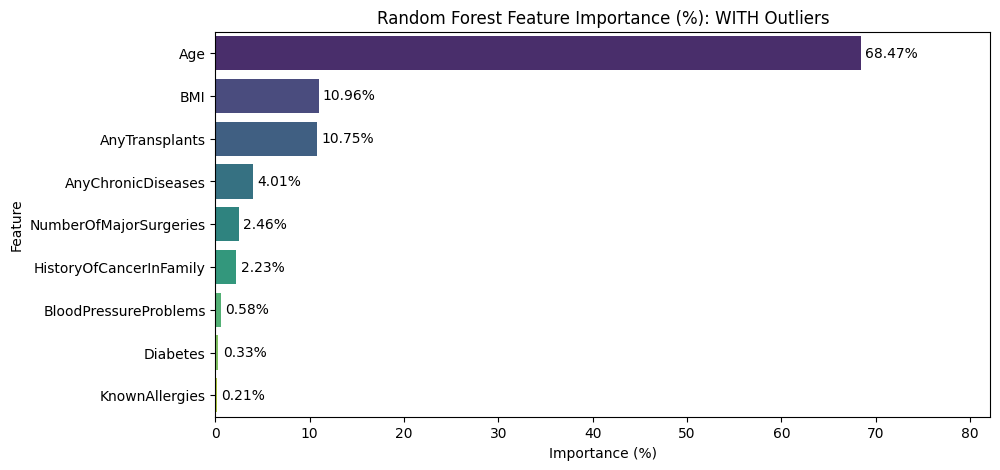

In [ ]:
# ==========================================================
# RANDOM FOREST - FULLY TUNED (WITH OUTLIERS) WITHOUT SCALING
# ==========================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Prepare features ---
# Drop target and unnecessary columns
X_train_rf = train_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_train_rf = train_data['PremiumPrice'].values
X_test_rf = test_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_test_rf = test_data['PremiumPrice'].values

# --- Step 2: Convert categorical columns to int (binary features) ---
categorical_cols = ["AnyTransplants", "Diabetes", "AnyChronicDiseases", 
                    "KnownAllergies", "HistoryOfCancerInFamily", "BloodPressureProblems"]

for col in categorical_cols:
    X_train_rf[col] = X_train_rf[col].astype(int)
    X_test_rf[col] = X_test_rf[col].astype(int)

# --- Step 3: Hyperparameter tuning with Grid Search ---
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_rf.fit(X_train_rf, y_train_rf)

# Get the best estimator
rf_tuned = grid_rf.best_estimator_
print(f"Best Parameters (With Outliers): {grid_rf.best_params_}")

# --- Step 4: Predictions ---
y_train_pred_rf = rf_tuned.predict(X_train_rf)
y_test_pred_rf = rf_tuned.predict(X_test_rf)

# --- Step 5: Performance table ---
performance_rf = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [mean_squared_error(y_train_rf, y_train_pred_rf), mean_squared_error(y_test_rf, y_test_pred_rf)],
    "RMSE": [np.sqrt(mean_squared_error(y_train_rf, y_train_pred_rf)), np.sqrt(mean_squared_error(y_test_rf, y_test_pred_rf))],
    "MAE": [mean_absolute_error(y_train_rf, y_train_pred_rf), mean_absolute_error(y_test_rf, y_test_pred_rf)],
    "R_squared": [r2_score(y_train_rf, y_train_pred_rf), r2_score(y_test_rf, y_test_pred_rf)]
})

print("\nRandom Forest Performance - WITH Outliers (Fully Tuned, No Scaling)")
print(performance_rf)

# --- Step 6: Feature Importance Plot ---
importances_rf = rf_tuned.feature_importances_ * 100
df_rf = pd.DataFrame({'Feature': X_train_rf.columns, 'Importance (%)': importances_rf}) \
        .sort_values('Importance (%)', ascending=False)

plt.figure(figsize=(10, 5))
ax1 = sns.barplot(x='Importance (%)', y='Feature', data=df_rf, palette='viridis')
for i in ax1.containers: 
    ax1.bar_label(i, fmt='%.2f%%', padding=3)

plt.title('Random Forest Feature Importance (%): WITH Outliers')
plt.xlim(0, df_rf['Importance (%)'].max() * 1.2)
plt.show()


Best Hyperparameters:
{'max_depth': 15, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}

OOB R² Score: 0.7213058990481311

FINAL RANDOM FOREST PERFORMANCE
    Dataset           MSE         RMSE          MAE  R_squared
0  Training  6.204853e+06  2490.954151  1310.217088   0.836981
1   Testing  6.168589e+06  2483.664444  1641.218185   0.855343


C:\Users\sahan\AppData\Local\Temp\ipykernel_12416\3230060429.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


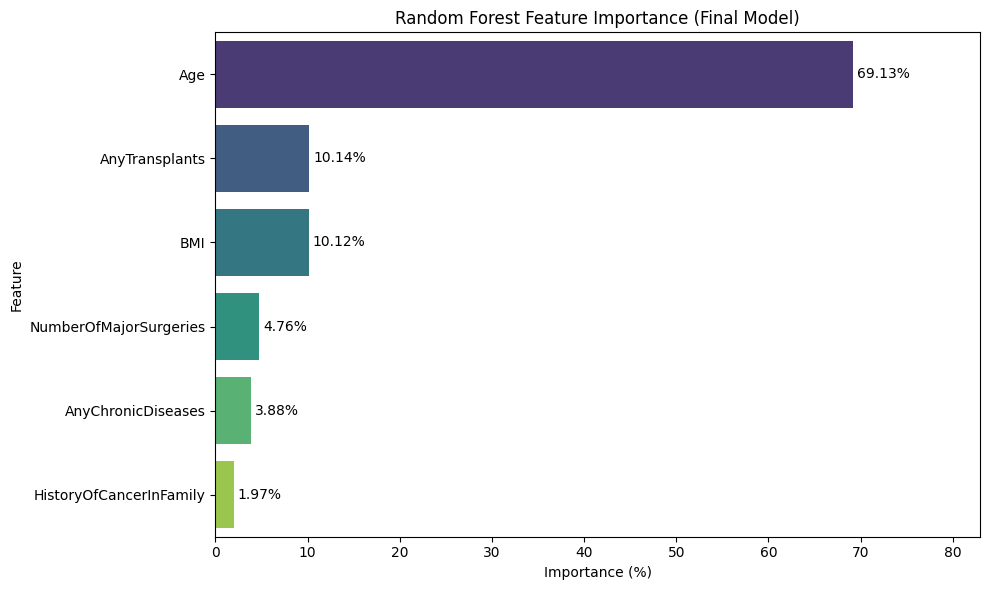

In [ ]:
# ==========================================================
# FINAL RANDOM FOREST REGRESSION MODEL (WITH OUTLIERS)
# OOB VALIDATED + REGULARIZED + REPORT READY
# ==========================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# Step 1: Prepare features
# ----------------------------------------------------------

to_drop = [
    'PremiumPrice',
    'Height',
    'Weight',
    'KnownAllergies',
    'Diabetes',
    'BloodPressureProblems',
]

X_train_rf = train_data.drop(columns=to_drop)
y_train_rf = train_data['PremiumPrice'].values

X_test_rf = test_data.drop(columns=to_drop)
y_test_rf = test_data['PremiumPrice'].values

# ----------------------------------------------------------
# Step 2: Safe categorical conversion (binary only)
# ----------------------------------------------------------

categorical_cols = [
    "AnyTransplants",
    "Diabetes",
    "AnyChronicDiseases",
    "KnownAllergies",
    "HistoryOfCancerInFamily",
    "BloodPressureProblems"
]

for col in categorical_cols:
    if col in X_train_rf.columns:
        X_train_rf[col] = X_train_rf[col].astype(int)
        X_test_rf[col] = X_test_rf[col].astype(int)

# ----------------------------------------------------------
# Step 3: Hyperparameter grid (regularized)
# ----------------------------------------------------------

param_grid_rf = {
    'n_estimators': [200, 300],
    'max_depth': [10, 15],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5],
    'max_features': ['sqrt', 0.5]
}

# ----------------------------------------------------------
# Step 4: GridSearch with OOB validation
# ----------------------------------------------------------

grid_rf = GridSearchCV(
    RandomForestRegressor(
        random_state=42,
        oob_score=True,
        bootstrap=True
    ),
    param_grid_rf,
    cv=10,
    scoring='r2',
    n_jobs=-1
)

grid_rf.fit(X_train_rf, y_train_rf)

rf_final = grid_rf.best_estimator_

print("Best Hyperparameters:")
print(grid_rf.best_params_)
print("\nOOB R² Score:", rf_final.oob_score_)

# ----------------------------------------------------------
# Step 5: Predictions
# ----------------------------------------------------------

y_train_pred = rf_final.predict(X_train_rf)
y_test_pred = rf_final.predict(X_test_rf)

# ----------------------------------------------------------
# Step 6: Performance table
# ----------------------------------------------------------

performance_rf = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [
        mean_squared_error(y_train_rf, y_train_pred),
        mean_squared_error(y_test_rf, y_test_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train_rf, y_train_pred)),
        np.sqrt(mean_squared_error(y_test_rf, y_test_pred))
    ],
    "MAE": [
        mean_absolute_error(y_train_rf, y_train_pred),
        mean_absolute_error(y_test_rf, y_test_pred)
    ],
    "R_squared": [
        r2_score(y_train_rf, y_train_pred),
        r2_score(y_test_rf, y_test_pred)
    ]
})

print("\nFINAL RANDOM FOREST PERFORMANCE")
print(performance_rf)

# ----------------------------------------------------------
# Step 7: Feature importance plot
# ----------------------------------------------------------

importances = rf_final.feature_importances_ * 100

df_importance = pd.DataFrame({
    'Feature': X_train_rf.columns,
    'Importance (%)': importances
}).sort_values('Importance (%)', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='Importance (%)',
    y='Feature',
    data=df_importance,
    palette='viridis'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.title('Random Forest Feature Importance (Final Model)')
plt.xlim(0, df_importance['Importance (%)'].max() * 1.2)
plt.tight_layout()
plt.show()


In [ ]:
import pickle

# Save the trained Random Forest model
with open("final_rf_model.pkl", "wb") as f:
    pickle.dump(rf_final, f)

print("Random Forest model saved as final_rf_model.pkl")


Random Forest model saved as final_rf_model.pkl


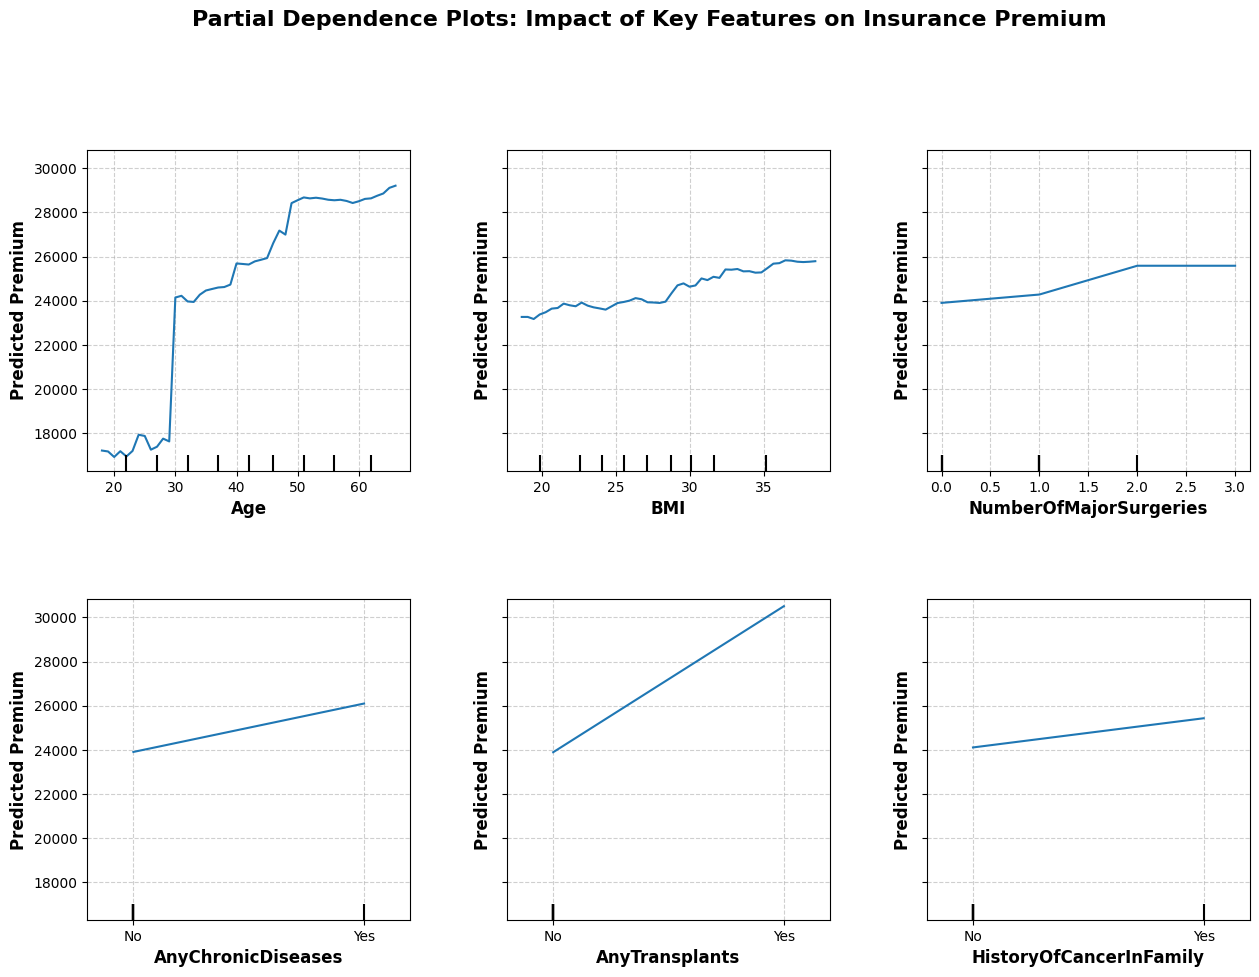

In [ ]:
# ==========================================================
# SINGLE IMAGE PDP (WITH "YES/NO" LABELS)
# ==========================================================

from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# 1. Setup Data
X_pdp = X_train_rf.copy().astype(float)

# 2. Define Features
all_features = [
    "Age",
    "BMI",
    "NumberOfMajorSurgeries",
    "AnyChronicDiseases",
    "AnyTransplants",
    "HistoryOfCancerInFamily"
]

# 3. Identify which ones are binary (to change labels later)
binary_vars = [
    "AnyChronicDiseases", 
    "AnyTransplants", 
    "HistoryOfCancerInFamily"
]

# 4. Create Figure
fig, ax = plt.subplots(figsize=(15, 10))

# 5. Generate Plots
display = PartialDependenceDisplay.from_estimator(
    estimator=rf_final,
    X=X_pdp,
    features=all_features,
    kind='average',
    n_cols=3,
    grid_resolution=50,
    ax=ax
)

# 6. Styling & "Yes/No" Labeling
display.figure_.subplots_adjust(hspace=0.4, wspace=0.3)

# Flatten the array of axes to loop through them easily
axes_list = display.axes_.flatten()

for i, ax_flat in enumerate(axes_list):
    if ax_flat:
        # Get the feature name for this specific subplot
        # (The features are plotted in the order of the 'all_features' list)
        feature_name = all_features[i]
        
        # Style the labels
        ax_flat.set_xlabel(feature_name, fontsize=12, fontweight='bold')
        ax_flat.set_ylabel("Predicted Premium", fontsize=12, fontweight='bold')
        ax_flat.grid(True, linestyle='--', alpha=0.6)
        
        # --- THE FIX: Check if this feature is binary ---
        if feature_name in binary_vars:
            ax_flat.set_xticks([0, 1])          # Set ticks exactly at 0 and 1
            ax_flat.set_xticklabels(['No', 'Yes']) # Replace them with text
            
            # Optional: Add a little padding to x-axis so points aren't on the edge
            ax_flat.set_xlim(-0.2, 1.2) 

# 7. Final Title and Show
plt.suptitle(
    "Partial Dependence Plots: Impact of Key Features on Insurance Premium", 
    fontsize=16, 
    fontweight='bold', 
    y=1.02
)

plt.show()

In [ ]:
# ==========================================================
# RANDOM FOREST - FULLY TUNED (WITHOUT OUTLIERS, NO SCALING)
# ==========================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Prepare features ---
X_train_rf_clean = train_clean.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_train_rf_clean = train_clean['PremiumPrice'].values
X_test_rf_clean = test_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_test_rf_clean = test_data['PremiumPrice'].values

# --- Step 2: Convert categorical columns to int (binary features) ---
categorical_cols = ["AnyTransplants", "Diabetes", "AnyChronicDiseases", 
                    "KnownAllergies", "HistoryOfCancerInFamily", "BloodPressureProblems"]

for col in categorical_cols:
    X_train_rf_clean[col] = X_train_rf_clean[col].astype(int)
    X_test_rf_clean[col] = X_test_rf_clean[col].astype(int)

# --- Step 3: Hyperparameter Tuning with Grid Search ---
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_rf_clean = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_rf_clean.fit(X_train_rf_clean, y_train_rf_clean)

rf_clean_tuned = grid_rf_clean.best_estimator_
print(f"Best Parameters (Without Outliers): {grid_rf_clean.best_params_}")

# --- Step 4: Predictions ---
y_train_pred_rf_clean = rf_clean_tuned.predict(X_train_rf_clean)
y_test_pred_rf_clean = rf_clean_tuned.predict(X_test_rf_clean)

# --- Step 5: Performance table ---
performance_rf_clean = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [mean_squared_error(y_train_rf_clean, y_train_pred_rf_clean), mean_squared_error(y_test_rf_clean, y_test_pred_rf_clean)],
    "RMSE": [np.sqrt(mean_squared_error(y_train_rf_clean, y_train_pred_rf_clean)), np.sqrt(mean_squared_error(y_test_rf_clean, y_test_pred_rf_clean))],
    "MAE": [mean_absolute_error(y_train_rf_clean, y_train_pred_rf_clean), mean_absolute_error(y_test_rf_clean, y_test_pred_rf_clean)],
    "R_squared": [r2_score(y_train_rf_clean, y_train_pred_rf_clean), r2_score(y_test_rf_clean, y_test_pred_rf_clean)]
})

print("\nRandom Forest Performance - WITHOUT Outliers (Fully Tuned, No Scaling)")
print(performance_rf_clean)

# --- Step 6: Feature Importance Plot ---
importances_rf_clean = rf_clean_tuned.feature_importances_ * 100
df_rf_clean = pd.DataFrame({'Feature': X_train_rf_clean.columns, 'Importance (%)': importances_rf_clean}) \
              .sort_values('Importance (%)', ascending=False)

plt.figure(figsize=(10, 5))
ax2 = sns.barplot(x='Importance (%)', y='Feature', data=df_rf_clean, palette='viridis')
for i in ax2.containers: 
    ax2.bar_label(i, fmt='%.2f%%', padding=3)

plt.title('Random Forest Feature Importance (%): WITHOUT Outliers')
plt.xlim(0, df_rf_clean['Importance (%)'].max() * 1.2)
plt.show()


In [ ]:
# ==========================================================
# RANDOM FOREST - FULLY TUNED + FEATURE SELECTION (WITHOUT OUTLIERS)       'KnownAllergies','Diabetes','BloodPressureProblems','HistoryOfCancerInFamily','NumberOfMajorSurgeries'
# ==========================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Prepare features (Edit the drop list here) ---
# Add any features you want to remove into this list (e.g., 'KnownAllergies')
to_drop = ['PremiumPrice', 'Height', 'Weight', 'KnownAllergies','Diabetes','BloodPressureProblems'] 

X_train_rf_clean = train_clean.drop(columns=to_drop)
y_train_rf_clean = train_clean['PremiumPrice'].values

X_test_rf_clean = test_data.drop(columns=to_drop)
y_test_rf_clean = test_data['PremiumPrice'].values

# --- Step 2: Safe Categorical Conversion ---
# This ensures code doesn't crash if you drop a categorical column
for col in categorical_cols:
    if col in X_train_rf_clean.columns:
        X_train_rf_clean[col] = X_train_rf_clean[col].astype(int)
        X_test_rf_clean[col] = X_test_rf_clean[col].astype(int)

# --- Step 3: Scaling ---
scaler_rf_clean = StandardScaler()
X_train_rf_clean_scaled = scaler_rf_clean.fit_transform(X_train_rf_clean)
X_test_rf_clean_scaled = scaler_rf_clean.transform(X_test_rf_clean)

# --- Step 4: Hyperparameter Tuning with Grid Search ---
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_rf_clean = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
grid_rf_clean.fit(X_train_rf_clean_scaled, y_train_rf_clean)

rf_clean_tuned = grid_rf_clean.best_estimator_
print(f"Best Parameters (Without Outliers): {grid_rf_clean.best_params_}")

# --- Step 5: Predictions ---
y_train_pred_rf_clean = rf_clean_tuned.predict(X_train_rf_clean_scaled)
y_test_pred_rf_clean = rf_clean_tuned.predict(X_test_rf_clean_scaled)

# --- Step 6: Performance table ---
performance_rf_clean = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [mean_squared_error(y_train_rf_clean, y_train_pred_rf_clean), mean_squared_error(y_test_rf_clean, y_test_pred_rf_clean)],
    "RMSE": [np.sqrt(mean_squared_error(y_train_rf_clean, y_train_pred_rf_clean)), np.sqrt(mean_squared_error(y_test_rf_clean, y_test_pred_rf_clean))],
    "MAE": [mean_absolute_error(y_train_rf_clean, y_train_pred_rf_clean), mean_absolute_error(y_test_rf_clean, y_test_pred_rf_clean)],
    "R_squared": [r2_score(y_train_rf_clean, y_train_pred_rf_clean), r2_score(y_test_rf_clean, y_test_pred_rf_clean)]
})

print("\nRandom Forest Performance - WITHOUT Outliers (After Selection)")
print(performance_rf_clean)

# --- Step 7: Feature Importance Plot (Fixed Warning) ---
importances_rf_clean = rf_clean_tuned.feature_importances_ * 100
df_rf_clean = pd.DataFrame({'Feature': X_train_rf_clean.columns, 'Importance (%)': importances_rf_clean}).sort_values('Importance (%)', ascending=False)

plt.figure(figsize=(10, 5))
# FIX: Added hue='Feature' and legend=False to remove the Future Warning
ax2 = sns.barplot(x='Importance (%)', y='Feature', data=df_rf_clean, palette='viridis', hue='Feature', legend=False)
for i in ax2.containers: 
    ax2.bar_label(i, fmt='%.2f%%', padding=3)

plt.title('Random Forest Importance (%): WITHOUT Outliers')
plt.xlim(0, df_rf_clean['Importance (%)'].max() * 1.2)
plt.show()

In [ ]:
# ==========================================================
# ADABOOST - FULLY TUNED (WITH OUTLIERS, NO SCALING)
# ==========================================================

from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Prepare features ---
X_train_ada = train_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_train_ada = train_data['PremiumPrice'].values
X_test_ada = test_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_test_ada = test_data['PremiumPrice'].values

# --- Step 2: Convert categorical columns to int ---
categorical_cols = ["AnyTransplants", "Diabetes", "AnyChronicDiseases", 
                    "KnownAllergies", "HistoryOfCancerInFamily", "BloodPressureProblems"]

for col in categorical_cols:
    X_train_ada[col] = X_train_ada[col].astype(int)
    X_test_ada[col] = X_test_ada[col].astype(int)

# --- Step 3: Hyperparameter Tuning ---
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 1.0],
    'loss': ['linear', 'square', 'exponential']
}

grid_ada = GridSearchCV(
    AdaBoostRegressor(random_state=42),
    param_grid_ada,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_ada.fit(X_train_ada, y_train_ada)

ada_tuned = grid_ada.best_estimator_
print(f"Best Parameters (With Outliers): {grid_ada.best_params_}")

# --- Step 4: Predictions ---
y_train_pred_ada = ada_tuned.predict(X_train_ada)
y_test_pred_ada = ada_tuned.predict(X_test_ada)

# --- Step 5: Performance Table ---
performance_ada = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [mean_squared_error(y_train_ada, y_train_pred_ada), mean_squared_error(y_test_ada, y_test_pred_ada)],
    "RMSE": [np.sqrt(mean_squared_error(y_train_ada, y_train_pred_ada)), np.sqrt(mean_squared_error(y_test_ada, y_test_pred_ada))],
    "MAE": [mean_absolute_error(y_train_ada, y_train_pred_ada), mean_absolute_error(y_test_ada, y_test_pred_ada)],
    "R_squared": [r2_score(y_train_ada, y_train_pred_ada), r2_score(y_test_ada, y_test_pred_ada)]
})

print("\nAdaBoost Performance - WITH Outliers (Fully Tuned, No Scaling)")
print(performance_ada)

# --- Step 6: Feature Importance Plot ---
importances_ada = ada_tuned.feature_importances_ * 100
df_ada = pd.DataFrame({'Feature': X_train_ada.columns, 'Importance (%)': importances_ada}) \
         .sort_values('Importance (%)', ascending=False)

plt.figure(figsize=(10, 5))
ax5 = sns.barplot(x='Importance (%)', y='Feature', data=df_ada, palette='plasma')
for i in ax5.containers: 
    ax5.bar_label(i, fmt='%.2f%%', padding=3)

plt.title('AdaBoost Feature Importance (%): WITH Outliers')
plt.xlim(0, df_ada['Importance (%)'].max() * 1.2)
plt.show()


In [ ]:
# ==========================================================
# ADABOOST - FULLY TUNED + FEATURE SELECTION (WITH OUTLIERS)           'KnownAllergies','Diabetes','BloodPressureProblems','HistoryOfCancerInFamily','NumberOfMajorSurgeries'
# ==========================================================

from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Prepare features (Edit the drop list here) ---
# Add any unimportant features you want to remove into this list
to_drop = ['PremiumPrice', 'Height', 'Weight','KnownAllergies','Diabetes','HistoryOfCancerInFamily','NumberOfMajorSurgeries'] 

X_train_ada = train_data.drop(columns=to_drop)
y_train_ada = train_data['PremiumPrice'].values
X_test_ada = test_data.drop(columns=to_drop)
y_test_ada = test_data['PremiumPrice'].values

# --- Step 2: Safe Categorical Conversion ---
# This ensures code doesn't crash if you drop a categorical column
for col in categorical_cols:
    if col in X_train_ada.columns:
        X_train_ada[col] = X_train_ada[col].astype(int)
        X_test_ada[col] = X_test_ada[col].astype(int)

# --- Step 3: Scaling ---
scaler_ada = StandardScaler()
X_train_ada_scaled = scaler_ada.fit_transform(X_train_ada)
X_test_ada_scaled = scaler_ada.transform(X_test_ada)

# --- Step 4: Hyperparameter Tuning ---
# We use a DecisionTreeRegressor as the base_estimator
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 1.0],
    'loss': ['linear', 'square', 'exponential']
}

grid_ada = GridSearchCV(AdaBoostRegressor(random_state=42), param_grid_ada, cv=5, scoring='r2', n_jobs=-1)
grid_ada.fit(X_train_ada_scaled, y_train_ada)

ada_tuned = grid_ada.best_estimator_
print(f"Best Parameters (With Outliers): {grid_ada.best_params_}")

# --- Step 5: Predictions ---
y_train_pred_ada = ada_tuned.predict(X_train_ada_scaled)
y_test_pred_ada = ada_tuned.predict(X_test_ada_scaled)

# --- Step 6: Performance Table ---
performance_ada = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [mean_squared_error(y_train_ada, y_train_pred_ada), mean_squared_error(y_test_ada, y_test_pred_ada)],
    "RMSE": [np.sqrt(mean_squared_error(y_train_ada, y_train_pred_ada)), np.sqrt(mean_squared_error(y_test_ada, y_test_pred_ada))],
    "MAE": [mean_absolute_error(y_train_ada, y_train_pred_ada), mean_absolute_error(y_test_ada, y_test_pred_ada)],
    "R_squared": [r2_score(y_train_ada, y_train_pred_ada), r2_score(y_test_ada, y_test_pred_ada)]
})

print("\nAdaBoost Performance - WITH Outliers (After Selection)")
print(performance_ada)

# --- Step 7: Feature Importance Plot (Fixed Warning) ---
importances_ada = ada_tuned.feature_importances_ * 100
df_ada = pd.DataFrame({'Feature': X_train_ada.columns, 'Importance (%)': importances_ada}).sort_values('Importance (%)', ascending=False)

plt.figure(figsize=(10, 5))
# FIX: Added hue='Feature' and legend=False to remove the Future Warning
ax5 = sns.barplot(x='Importance (%)', y='Feature', data=df_ada, palette='plasma', hue='Feature', legend=False)
for i in ax5.containers: 
    ax5.bar_label(i, fmt='%.2f%%', padding=3)

plt.title('AdaBoost Importance (%): WITH Outliers')
plt.xlim(0, df_ada['Importance (%)'].max() * 1.2)
plt.show()

In [ ]:
# ==========================================================
# ADABOOST - FULLY TUNED (WITHOUT OUTLIERS, NO SCALING)
# ==========================================================

from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Prepare features ---
X_train_ada_clean = train_clean.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_train_ada_clean = train_clean['PremiumPrice'].values
X_test_ada_clean = test_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_test_ada_clean = test_data['PremiumPrice'].values

# --- Step 2: Convert categorical columns to int ---
categorical_cols = ["AnyTransplants", "Diabetes", "AnyChronicDiseases", 
                    "KnownAllergies", "HistoryOfCancerInFamily", "BloodPressureProblems"]

for col in categorical_cols:
    X_train_ada_clean[col] = X_train_ada_clean[col].astype(int)
    X_test_ada_clean[col] = X_test_ada_clean[col].astype(int)

# --- Step 3: Hyperparameter Tuning ---
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 1.0],
    'loss': ['linear', 'square', 'exponential']
}

grid_ada_clean = GridSearchCV(
    AdaBoostRegressor(random_state=42),
    param_grid_ada,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_ada_clean.fit(X_train_ada_clean, y_train_ada_clean)

ada_clean_tuned = grid_ada_clean.best_estimator_
print(f"Best Parameters (Without Outliers): {grid_ada_clean.best_params_}")

# --- Step 4: Predictions ---
y_train_pred_ada_clean = ada_clean_tuned.predict(X_train_ada_clean)
y_test_pred_ada_clean = ada_clean_tuned.predict(X_test_ada_clean)

# --- Step 5: Performance Table ---
performance_ada_clean = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [mean_squared_error(y_train_ada_clean, y_train_pred_ada_clean), mean_squared_error(y_test_ada_clean, y_test_pred_ada_clean)],
    "RMSE": [np.sqrt(mean_squared_error(y_train_ada_clean, y_train_pred_ada_clean)), np.sqrt(mean_squared_error(y_test_ada_clean, y_test_pred_ada_clean))],
    "MAE": [mean_absolute_error(y_train_ada_clean, y_train_pred_ada_clean), mean_absolute_error(y_test_ada_clean, y_test_pred_ada_clean)],
    "R_squared": [r2_score(y_train_ada_clean, y_train_pred_ada_clean), r2_score(y_test_ada_clean, y_test_pred_ada_clean)]
})

print("\nAdaBoost Performance - WITHOUT Outliers (Fully Tuned, No Scaling)")
print(performance_ada_clean)

# --- Step 6: Feature Importance Plot ---
importances_ada_clean = ada_clean_tuned.feature_importances_ * 100
df_ada_clean = pd.DataFrame({'Feature': X_train_ada_clean.columns, 'Importance (%)': importances_ada_clean}) \
               .sort_values('Importance (%)', ascending=False)

plt.figure(figsize=(10, 5))
ax6 = sns.barplot(x='Importance (%)', y='Feature', data=df_ada_clean, palette='plasma')
for i in ax6.containers: 
    ax6.bar_label(i, fmt='%.2f%%', padding=3)

plt.title('AdaBoost Feature Importance (%): WITHOUT Outliers')
plt.xlim(0, df_ada_clean['Importance (%)'].max() * 1.2)
plt.show()


In [ ]:
# ==========================================================
# ADABOOST - FULLY TUNED + FEATURE SELECTION (WITHOUT OUTLIERS)  'KnownAllergies','Diabetes','BloodPressureProblems','HistoryOfCancerInFamily','NumberOfMajorSurgeries'
# ==========================================================

from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Prepare features (Edit the drop list here) ---
# Add any unimportant features you want to remove into this list
to_drop = ['PremiumPrice', 'Height', 'Weight','KnownAllergies','Diabetes','BloodPressureProblems','HistoryOfCancerInFamily','NumberOfMajorSurgeries'] 

X_train_ada_clean = train_clean.drop(columns=to_drop)
y_train_ada_clean = train_clean['PremiumPrice'].values

# For testing, we use the original test_data (198 rows)
X_test_ada_clean = test_data.drop(columns=to_drop)
y_test_ada_clean = test_data['PremiumPrice'].values

# --- Step 2: Safe Categorical Conversion ---
# This check prevents errors if you decide to drop a categorical feature
for col in categorical_cols:
    if col in X_train_ada_clean.columns:
        X_train_ada_clean[col] = X_train_ada_clean[col].astype(int)
        X_test_ada_clean[col] = X_test_ada_clean[col].astype(int)

# --- Step 3: Scaling ---
scaler_ada_clean = StandardScaler()
X_train_ada_clean_scaled = scaler_ada_clean.fit_transform(X_train_ada_clean)
X_test_ada_clean_scaled = scaler_ada_clean.transform(X_test_ada_clean)

# --- Step 4: Hyperparameter Tuning ---
grid_ada_clean = GridSearchCV(AdaBoostRegressor(random_state=42), param_grid_ada, cv=5, scoring='r2', n_jobs=-1)
grid_ada_clean.fit(X_train_ada_clean_scaled, y_train_ada_clean)

ada_clean_tuned = grid_ada_clean.best_estimator_
print(f"Best Parameters (Without Outliers): {grid_ada_clean.best_params_}")

# --- Step 5: Predictions ---
y_train_pred_ada_clean = ada_clean_tuned.predict(X_train_ada_clean_scaled)
y_test_pred_ada_clean = ada_clean_tuned.predict(X_test_ada_clean_scaled)

# --- Step 6: Performance Table ---
performance_ada_clean = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [mean_squared_error(y_train_ada_clean, y_train_pred_ada_clean), mean_squared_error(y_test_ada_clean, y_test_pred_ada_clean)],
    "RMSE": [np.sqrt(mean_squared_error(y_train_ada_clean, y_train_pred_ada_clean)), np.sqrt(mean_squared_error(y_test_ada_clean, y_test_pred_ada_clean))],
    "MAE": [mean_absolute_error(y_train_ada_clean, y_train_pred_ada_clean), mean_absolute_error(y_test_ada_clean, y_test_pred_ada_clean)],
    "R_squared": [r2_score(y_train_ada_clean, y_train_pred_ada_clean), r2_score(y_test_ada_clean, y_test_pred_ada_clean)]
})

print("\nAdaBoost Performance - WITHOUT Outliers (After Selection)")
print(performance_ada_clean)

# --- Step 7: Feature Importance Plot (Fixed Warning) ---
importances_ada_clean = ada_clean_tuned.feature_importances_ * 100
df_ada_clean = pd.DataFrame({'Feature': X_train_ada_clean.columns, 'Importance (%)': importances_ada_clean}).sort_values('Importance (%)', ascending=False)

plt.figure(figsize=(10, 5))
# FIX: Added hue='Feature' and legend=False to remove the Future Warning
ax6 = sns.barplot(x='Importance (%)', y='Feature', data=df_ada_clean, palette='plasma', hue='Feature', legend=False)
for i in ax6.containers: 
    ax6.bar_label(i, fmt='%.2f%%', padding=3)

plt.title('AdaBoost Importance (%): WITHOUT Outliers')
plt.xlim(0, df_ada_clean['Importance (%)'].max() * 1.2)
plt.show()

In [ ]:
# ==========================================================
# GRADIENT BOOSTING - FULLY TUNED (WITH OUTLIERS, NO SCALING)
# ==========================================================

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Prepare features ---
X_train_gb = train_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_train_gb = train_data['PremiumPrice'].values
X_test_gb = test_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_test_gb = test_data['PremiumPrice'].values

# --- Step 2: Convert categorical columns to int ---
categorical_cols = ["AnyTransplants", "Diabetes", "AnyChronicDiseases", 
                    "KnownAllergies", "HistoryOfCancerInFamily", "BloodPressureProblems"]

for col in categorical_cols:
    X_train_gb[col] = X_train_gb[col].astype(int)
    X_test_gb[col] = X_test_gb[col].astype(int)

# --- Step 3: Hyperparameter Tuning ---
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_gb.fit(X_train_gb, y_train_gb)

gb_tuned = grid_gb.best_estimator_
print(f"Best Parameters (With Outliers): {grid_gb.best_params_}")

# --- Step 4: Predictions ---
y_train_pred_gb = gb_tuned.predict(X_train_gb)
y_test_pred_gb = gb_tuned.predict(X_test_gb)

# --- Step 5: Performance Table ---
performance_gb = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [mean_squared_error(y_train_gb, y_train_pred_gb), mean_squared_error(y_test_gb, y_test_pred_gb)],
    "RMSE": [np.sqrt(mean_squared_error(y_train_gb, y_train_pred_gb)), np.sqrt(mean_squared_error(y_test_gb, y_test_pred_gb))],
    "MAE": [mean_absolute_error(y_train_gb, y_train_pred_gb), mean_absolute_error(y_test_gb, y_test_pred_gb)],
    "R_squared": [r2_score(y_train_gb, y_train_pred_gb), r2_score(y_test_gb, y_test_pred_gb)]
})

print("\nGradient Boosting Performance - WITH Outliers (Fully Tuned, No Scaling)")
print(performance_gb)

# --- Step 6: Feature Importance Plot ---
importances_gb = gb_tuned.feature_importances_ * 100
df_gb = pd.DataFrame({'Feature': X_train_gb.columns, 'Importance (%)': importances_gb}) \
        .sort_values('Importance (%)', ascending=False)

plt.figure(figsize=(10, 5))
ax3 = sns.barplot(x='Importance (%)', y='Feature', data=df_gb, palette='magma')
for i in ax3.containers:
    ax3.bar_label(i, fmt='%.2f%%', padding=3)

plt.title('Gradient Boosting Feature Importance (%): WITH Outliers')
plt.xlim(0, df_gb['Importance (%)'].max() * 1.2)
plt.show()


In [ ]:
# ==========================================================
# GRADIENT BOOSTING - FULLY TUNED + FEATURE SELECTION (WITH OUTLIERS)- -removing only 'KnownAllergies','Diabetes','BloodPressureProblems','HistoryOfCancerInFamily'


# ==========================================================

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Prepare features (Edit the drop list here) ---
# Add any features you want to remove to this list
to_drop = ['PremiumPrice', 'Height', 'Weight','KnownAllergies','Diabetes','BloodPressureProblems','HistoryOfCancerInFamily'] 

X_train_gb = train_data.drop(columns=to_drop)
y_train_gb = train_data['PremiumPrice'].values
X_test_gb = test_data.drop(columns=to_drop)
y_test_gb = test_data['PremiumPrice'].values

# --- NEW: Categorical Safety Check ---
for col in categorical_cols:
    if col in X_train_gb.columns: # Prevents error if you dropped a categorical col
        X_train_gb[col] = X_train_gb[col].astype(int)
        X_test_gb[col] = X_test_gb[col].astype(int)

# --- Step 2: Scaling ---
scaler_gb = StandardScaler()
X_train_gb_scaled = scaler_gb.fit_transform(X_train_gb)
X_test_gb_scaled = scaler_gb.transform(X_test_gb)

# --- Step 3: Hyperparameter Tuning ---
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

grid_gb = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid_gb, cv=5, scoring='r2', n_jobs=-1)
grid_gb.fit(X_train_gb_scaled, y_train_gb)

gb_tuned = grid_gb.best_estimator_
print(f"Best Parameters (With Outliers): {grid_gb.best_params_}")

# --- Step 4: Predictions ---
y_train_pred_gb = gb_tuned.predict(X_train_gb_scaled)
y_test_pred_gb = gb_tuned.predict(X_test_gb_scaled)

# --- Step 5: Performance Table ---
performance_gb = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [mean_squared_error(y_train_gb, y_train_pred_gb), mean_squared_error(y_test_gb, y_test_pred_gb)],
    "RMSE": [np.sqrt(mean_squared_error(y_train_gb, y_train_pred_gb)), np.sqrt(mean_squared_error(y_test_gb, y_test_pred_gb))],
    "MAE": [mean_absolute_error(y_train_gb, y_train_pred_gb), mean_absolute_error(y_test_gb, y_test_pred_gb)],
    "R_squared": [r2_score(y_train_gb, y_train_pred_gb), r2_score(y_test_gb, y_test_pred_gb)]
})

print("\nGradient Boosting Performance - WITH Outliers (After Feature Selection)")
print(performance_gb)

# --- Step 6: Feature Importance Plot (Fixed Warning) ---
importances_gb = gb_tuned.feature_importances_ * 100
df_gb = pd.DataFrame({'Feature': X_train_gb.columns, 'Importance (%)': importances_gb}).sort_values('Importance (%)', ascending=False)

plt.figure(figsize=(10, 5))
# FIXED: Added hue='Feature' and legend=False to remove Future Warning
ax3 = sns.barplot(x='Importance (%)', y='Feature', data=df_gb, palette='magma', hue='Feature', legend=False)
for i in ax3.containers: 
    ax3.bar_label(i, fmt='%.2f%%', padding=3)

plt.title('Gradient Boosting Importance (%): WITH Outliers')
plt.xlim(0, df_gb['Importance (%)'].max() * 1.2)
plt.show()

In [ ]:
# ==========================================================
# GRADIENT BOOSTING - FULLY TUNED (WITHOUT OUTLIERS, NO SCALING)
# ==========================================================

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Prepare features ---
X_train_gb_clean = train_clean.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_train_gb_clean = train_clean['PremiumPrice'].values
X_test_gb_clean = X_test_gb  # test_data prepared earlier
y_test_gb_clean = y_test_gb

# --- Step 2: Convert categorical columns to int ---
categorical_cols = ["AnyTransplants", "Diabetes", "AnyChronicDiseases", 
                    "KnownAllergies", "HistoryOfCancerInFamily", "BloodPressureProblems"]

for col in categorical_cols:
    X_train_gb_clean[col] = X_train_gb_clean[col].astype(int)
    X_test_gb_clean[col] = X_test_gb_clean[col].astype(int)

# --- Step 3: Hyperparameter Tuning ---
grid_gb_clean = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_gb_clean.fit(X_train_gb_clean, y_train_gb_clean)

gb_clean_tuned = grid_gb_clean.best_estimator_
print(f"Best Parameters (Without Outliers): {grid_gb_clean.best_params_}")

# --- Step 4: Predictions ---
y_train_pred_gb_clean = gb_clean_tuned.predict(X_train_gb_clean)
y_test_pred_gb_clean = gb_clean_tuned.predict(X_test_gb_clean)

# --- Step 5: Performance Table ---
performance_gb_clean = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [mean_squared_error(y_train_gb_clean, y_train_pred_gb_clean), mean_squared_error(y_test_gb_clean, y_test_pred_gb_clean)],
    "RMSE": [np.sqrt(mean_squared_error(y_train_gb_clean, y_train_pred_gb_clean)), np.sqrt(mean_squared_error(y_test_gb_clean, y_test_pred_gb_clean))],
    "MAE": [mean_absolute_error(y_train_gb_clean, y_train_pred_gb_clean), mean_absolute_error(y_test_gb_clean, y_test_pred_gb_clean)],
    "R_squared": [r2_score(y_train_gb_clean, y_train_pred_gb_clean), r2_score(y_test_gb_clean, y_test_pred_gb_clean)]
})

print("\nGradient Boosting Performance - WITHOUT Outliers (Fully Tuned, No Scaling)")
print(performance_gb_clean)

# --- Step 6: Feature Importance Plot ---
importances_gb_clean = gb_clean_tuned.feature_importances_ * 100
df_gb_clean = pd.DataFrame({'Feature': X_train_gb_clean.columns, 'Importance (%)': importances_gb_clean}) \
        .sort_values('Importance (%)', ascending=False)

plt.figure(figsize=(10, 5))
ax4 = sns.barplot(x='Importance (%)', y='Feature', data=df_gb_clean, palette='magma')
for i in ax4.containers:
    ax4.bar_label(i, fmt='%.2f%%', padding=3)

plt.title('Gradient Boosting Feature Importance (%): WITHOUT Outliers')
plt.xlim(0, df_gb_clean['Importance (%)'].max() * 1.2)
plt.show()


In [ ]:
# ==========================================================
# GRADIENT BOOSTING - FULLY TUNED + FEATURE SELECTION (WITHOUT OUTLIERS) 'KnownAllergies','Diabetes','BloodPressureProblems','HistoryOfCancerInFamily'
# ==========================================================

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Prepare features (Edit the drop list here) ---
# Add any unimportant features you want to remove into this list
to_drop = ['PremiumPrice', 'Height', 'Weight','KnownAllergies','Diabetes','BloodPressureProblems'] 

X_train_gb_clean = train_clean.drop(columns=to_drop)
y_train_gb_clean = train_clean['PremiumPrice'].values

# For testing, we use the original test_data prepared in earlier steps
X_test_gb_clean = test_data.drop(columns=to_drop)
y_test_gb_clean = test_data['PremiumPrice'].values

# --- Step 2: Safe Categorical Conversion ---
# This 'if' check ensures code doesn't crash if a categorical col is dropped
for col in categorical_cols:
    if col in X_train_gb_clean.columns:
        X_train_gb_clean[col] = X_train_gb_clean[col].astype(int)
        X_test_gb_clean[col] = X_test_gb_clean[col].astype(int)

# --- Step 3: Scaling ---
scaler_gb_clean = StandardScaler()
X_train_gb_clean_scaled = scaler_gb_clean.fit_transform(X_train_gb_clean)
X_test_gb_clean_scaled = scaler_gb_clean.transform(X_test_gb_clean)

# --- Step 4: Hyperparameter Tuning ---
grid_gb_clean = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid_gb, cv=5, scoring='r2', n_jobs=-1)
grid_gb_clean.fit(X_train_gb_clean_scaled, y_train_gb_clean)

gb_clean_tuned = grid_gb_clean.best_estimator_
print(f"Best Parameters (Without Outliers): {grid_gb_clean.best_params_}")

# --- Step 5: Predictions ---
y_train_pred_gb_clean = gb_clean_tuned.predict(X_train_gb_clean_scaled)
y_test_pred_gb_clean = gb_clean_tuned.predict(X_test_gb_clean_scaled)

# --- Step 6: Performance Table ---
performance_gb_clean = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [mean_squared_error(y_train_gb_clean, y_train_pred_gb_clean), mean_squared_error(y_test_gb_clean, y_test_pred_gb_clean)],
    "RMSE": [np.sqrt(mean_squared_error(y_train_gb_clean, y_train_pred_gb_clean)), np.sqrt(mean_squared_error(y_test_gb_clean, y_test_pred_gb_clean))],
    "MAE": [mean_absolute_error(y_train_gb_clean, y_train_pred_gb_clean), mean_absolute_error(y_test_gb_clean, y_test_pred_gb_clean)],
    "R_squared": [r2_score(y_train_gb_clean, y_train_pred_gb_clean), r2_score(y_test_gb_clean, y_test_pred_gb_clean)]
})

print("\nGradient Boosting Performance - WITHOUT Outliers (After Selection)")
print(performance_gb_clean)

# --- Step 7: Feature Importance Plot (Fixed Warning) ---
importances_gb_clean = gb_clean_tuned.feature_importances_ * 100
df_gb_clean = pd.DataFrame({'Feature': X_train_gb_clean.columns, 'Importance (%)': importances_gb_clean}).sort_values('Importance (%)', ascending=False)

plt.figure(figsize=(10, 5))
# FIX: Added hue='Feature' and legend=False to remove the Future Warning
ax4 = sns.barplot(x='Importance (%)', y='Feature', data=df_gb_clean, palette='magma', hue='Feature', legend=False)
for i in ax4.containers: 
    ax4.bar_label(i, fmt='%.2f%%', padding=3)

plt.title('Gradient Boosting Importance (%): WITHOUT Outliers')
plt.xlim(0, df_gb_clean['Importance (%)'].max() * 1.2)
plt.show()

In [ ]:
# ==========================================================
# XGBOOST - FULLY TUNED (WITH OUTLIERS, NO SCALING)
# ==========================================================

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Prepare features ---
X_train_xgb = train_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_train_xgb = train_data['PremiumPrice'].values
X_test_xgb = test_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_test_xgb = test_data['PremiumPrice'].values

# --- Step 2: Convert categorical columns to int ---
categorical_cols = ["AnyTransplants", "Diabetes", "AnyChronicDiseases", 
                    "KnownAllergies", "HistoryOfCancerInFamily", "BloodPressureProblems"]

for col in categorical_cols:
    X_train_xgb[col] = X_train_xgb[col].astype(int)
    X_test_xgb[col] = X_test_xgb[col].astype(int)

# --- Step 3: Hyperparameter Tuning ---
param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

grid_xgb = GridSearchCV(XGBRegressor(random_state=42), param_grid_xgb, cv=5, scoring='r2', n_jobs=-1)
grid_xgb.fit(X_train_xgb, y_train_xgb)

xgb_tuned = grid_xgb.best_estimator_
print(f"Best Parameters (With Outliers): {grid_xgb.best_params_}")

# --- Step 4: Predictions ---
y_train_pred_xgb = xgb_tuned.predict(X_train_xgb)
y_test_pred_xgb = xgb_tuned.predict(X_test_xgb)

# --- Step 5: Performance Table ---
performance_xgb = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [mean_squared_error(y_train_xgb, y_train_pred_xgb), mean_squared_error(y_test_xgb, y_test_pred_xgb)],
    "RMSE": [np.sqrt(mean_squared_error(y_train_xgb, y_train_pred_xgb)), np.sqrt(mean_squared_error(y_test_xgb, y_test_pred_xgb))],
    "MAE": [mean_absolute_error(y_train_xgb, y_train_pred_xgb), mean_absolute_error(y_test_xgb, y_test_pred_xgb)],
    "R_squared": [r2_score(y_train_xgb, y_train_pred_xgb), r2_score(y_test_xgb, y_test_pred_xgb)]
})

print("\nXGBoost Performance - WITH Outliers (Fully Tuned, No Scaling)")
print(performance_xgb)

# --- Step 6: Feature Importance Plot ---
importances_xgb = xgb_tuned.feature_importances_ * 100
df_imp = pd.DataFrame({'Feature': X_train_xgb.columns, 'Importance (%)': importances_xgb}).sort_values('Importance (%)', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Importance (%)', y='Feature', data=df_imp, palette='viridis')
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f%%', padding=3)

plt.title('XGBoost Feature Importance (%): WITH Outliers')
plt.xlabel('Percentage Contribution to Prediction')
plt.xlim(0, df_imp['Importance (%)'].max() * 1.15)
plt.show()


In [ ]:
# ==========================================================
# XGBOOST - FULLY TUNED (WITH OUTLIERS)                            #################      feature importance -removing only knownallergies.
# ==========================================================

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# --- Step 1: Prepare features ---
X_train_xgb = train_data.drop(columns=['PremiumPrice', 'Height', 'Weight','KnownAllergies'])
y_train_xgb = train_data['PremiumPrice'].values
X_test_xgb = test_data.drop(columns=['PremiumPrice', 'Height', 'Weight','KnownAllergies'])
y_test_xgb = test_data['PremiumPrice'].values

for col in categorical_cols:
    if col in X_train_xgb.columns:
         X_train_xgb[col] = X_train_xgb[col].astype(int)
         X_test_xgb[col] = X_test_xgb[col].astype(int)

   

# --- Step 2: Scaling ---
scaler_xgb = StandardScaler()
X_train_xgb_scaled = scaler_xgb.fit_transform(X_train_xgb)
X_test_xgb_scaled = scaler_xgb.transform(X_test_xgb)

# --- Step 3: Hyperparameter Tuning ---
# 'gamma' (min_split_loss) and 'lambda' (L2 reg) help prevent overfitting
param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

grid_xgb = GridSearchCV(XGBRegressor(random_state=42), param_grid_xgb, cv=5, scoring='r2', n_jobs=-1)
grid_xgb.fit(X_train_xgb_scaled, y_train_xgb)

xgb_tuned = grid_xgb.best_estimator_
print(f"Best Parameters (With Outliers): {grid_xgb.best_params_}")

# --- Step 4: Predictions ---
y_train_pred_xgb = xgb_tuned.predict(X_train_xgb_scaled)
y_test_pred_xgb = xgb_tuned.predict(X_test_xgb_scaled)

# --- Step 5: Performance Table ---
performance_xgb = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [mean_squared_error(y_train_xgb, y_train_pred_xgb), mean_squared_error(y_test_xgb, y_test_pred_xgb)],
    "RMSE": [np.sqrt(mean_squared_error(y_train_xgb, y_train_pred_xgb)), np.sqrt(mean_squared_error(y_test_xgb, y_test_pred_xgb))],
    "MAE": [mean_absolute_error(y_train_xgb, y_train_pred_xgb), mean_absolute_error(y_test_xgb, y_test_pred_xgb)],
    "R_squared": [r2_score(y_train_xgb, y_train_pred_xgb), r2_score(y_test_xgb, y_test_pred_xgb)]
})

print("\nXGBoost Performance - WITH Outliers (Fully Tuned)")
print(performance_xgb)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract and convert to percentages
importances_xgb = xgb_tuned.feature_importances_ * 100
features = X_train_xgb.columns
df_imp = pd.DataFrame({'Feature': features, 'Importance (%)': importances_xgb}).sort_values('Importance (%)', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Importance (%)', y='Feature', data=df_imp, palette='viridis')

# Add percentage labels to the bars
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f%%', padding=3)

plt.title('Total Feature Importance (%): XGBoost (With Outliers)')
plt.xlabel('Percentage Contribution to Prediction')
plt.xlim(0, df_imp['Importance (%)'].max() * 1.15) 
plt.show()

In [ ]:
# ==========================================================
# XGBOOST - FULLY TUNED (WITH OUTLIERS)                            #################      feature importance -removing only knownallergies.+diabetes
# ==========================================================

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# --- Step 1: Prepare features ---
X_train_xgb = train_data.drop(columns=['PremiumPrice', 'Height', 'Weight','KnownAllergies','Diabetes'])
y_train_xgb = train_data['PremiumPrice'].values
X_test_xgb = test_data.drop(columns=['PremiumPrice', 'Height', 'Weight','KnownAllergies','Diabetes'])
y_test_xgb = test_data['PremiumPrice'].values

for col in categorical_cols:
    if col in X_train_xgb.columns:
         X_train_xgb[col] = X_train_xgb[col].astype(int)
         X_test_xgb[col] = X_test_xgb[col].astype(int)

   

# --- Step 2: Scaling ---
scaler_xgb = StandardScaler()
X_train_xgb_scaled = scaler_xgb.fit_transform(X_train_xgb)
X_test_xgb_scaled = scaler_xgb.transform(X_test_xgb)

# --- Step 3: Hyperparameter Tuning ---
# 'gamma' (min_split_loss) and 'lambda' (L2 reg) help prevent overfitting
param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

grid_xgb = GridSearchCV(XGBRegressor(random_state=42), param_grid_xgb, cv=5, scoring='r2', n_jobs=-1)
grid_xgb.fit(X_train_xgb_scaled, y_train_xgb)

xgb_tuned = grid_xgb.best_estimator_
print(f"Best Parameters (With Outliers): {grid_xgb.best_params_}")

# --- Step 4: Predictions ---
y_train_pred_xgb = xgb_tuned.predict(X_train_xgb_scaled)
y_test_pred_xgb = xgb_tuned.predict(X_test_xgb_scaled)

# --- Step 5: Performance Table ---
performance_xgb = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [mean_squared_error(y_train_xgb, y_train_pred_xgb), mean_squared_error(y_test_xgb, y_test_pred_xgb)],
    "RMSE": [np.sqrt(mean_squared_error(y_train_xgb, y_train_pred_xgb)), np.sqrt(mean_squared_error(y_test_xgb, y_test_pred_xgb))],
    "MAE": [mean_absolute_error(y_train_xgb, y_train_pred_xgb), mean_absolute_error(y_test_xgb, y_test_pred_xgb)],
    "R_squared": [r2_score(y_train_xgb, y_train_pred_xgb), r2_score(y_test_xgb, y_test_pred_xgb)]
})

print("\nXGBoost Performance - WITH Outliers (Fully Tuned)")
print(performance_xgb)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract and convert to percentages
importances_xgb = xgb_tuned.feature_importances_ * 100
features = X_train_xgb.columns
df_imp = pd.DataFrame({'Feature': features, 'Importance (%)': importances_xgb}).sort_values('Importance (%)', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Importance (%)', y='Feature', data=df_imp, palette='viridis')

# Add percentage labels to the bars
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f%%', padding=3)

plt.title('Total Feature Importance (%): XGBoost (With Outliers)')
plt.xlabel('Percentage Contribution to Prediction')
plt.xlim(0, df_imp['Importance (%)'].max() * 1.15) 
plt.show()

In [ ]:
# ==========================================================
# XGBOOST - FULLY TUNED (WITHOUT OUTLIERS, NO SCALING)
# ==========================================================

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Prepare features ---
X_train_xgb_clean = train_clean.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_train_xgb_clean = train_clean['PremiumPrice'].values
X_test_xgb_clean = test_data.drop(columns=['PremiumPrice', 'Height', 'Weight'])
y_test_xgb_clean = test_data['PremiumPrice'].values

# --- Step 2: Convert categorical columns to int ---
categorical_cols = ["AnyTransplants", "Diabetes", "AnyChronicDiseases", 
                    "KnownAllergies", "HistoryOfCancerInFamily", "BloodPressureProblems"]

for col in categorical_cols:
    X_train_xgb_clean[col] = X_train_xgb_clean[col].astype(int)
    X_test_xgb_clean[col] = X_test_xgb_clean[col].astype(int)

# --- Step 3: Hyperparameter Tuning ---
grid_xgb_clean = GridSearchCV(XGBRegressor(random_state=42), param_grid_xgb, cv=5, scoring='r2', n_jobs=-1)
grid_xgb_clean.fit(X_train_xgb_clean, y_train_xgb_clean)

xgb_clean_tuned = grid_xgb_clean.best_estimator_
print(f"Best Parameters (Without Outliers): {grid_xgb_clean.best_params_}")

# --- Step 4: Predictions ---
y_train_pred_xgb_clean = xgb_clean_tuned.predict(X_train_xgb_clean)
y_test_pred_xgb_clean = xgb_clean_tuned.predict(X_test_xgb_clean)

# --- Step 5: Performance Table ---
performance_xgb_clean = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [mean_squared_error(y_train_xgb_clean, y_train_pred_xgb_clean), 
            mean_squared_error(y_test_xgb_clean, y_test_pred_xgb_clean)],
    "RMSE": [np.sqrt(mean_squared_error(y_train_xgb_clean, y_train_pred_xgb_clean)), 
             np.sqrt(mean_squared_error(y_test_xgb_clean, y_test_pred_xgb_clean))],
    "MAE": [mean_absolute_error(y_train_xgb_clean, y_train_pred_xgb_clean), 
            mean_absolute_error(y_test_xgb_clean, y_test_pred_xgb_clean)],
    "R_squared": [r2_score(y_train_xgb_clean, y_train_pred_xgb_clean), 
                  r2_score(y_test_xgb_clean, y_test_pred_xgb_clean)]
})

print("\nXGBoost Performance - WITHOUT Outliers (Fully Tuned, No Scaling)")
print(performance_xgb_clean)

# --- Step 6: Feature Importance Plot ---
importances_xgb_clean = xgb_clean_tuned.feature_importances_ * 100
df_imp_clean = pd.DataFrame({'Feature': X_train_xgb_clean.columns, 'Importance (%)': importances_xgb_clean}).sort_values('Importance (%)', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Importance (%)', y='Feature', data=df_imp_clean, palette='magma')
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f%%', padding=3)

plt.title('XGBoost Feature Importance (%): WITHOUT Outliers')
plt.xlabel('Percentage Contribution to Prediction')
plt.xlim(0, df_imp_clean['Importance (%)'].max() * 1.15)
plt.show()


In [ ]:
# ==========================================================
# XGBOOST - FULLY TUNED + FEATURE SELECTION (WITHOUT OUTLIERS, NO SCALING)
# ==========================================================

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Prepare features after dropping unimportant ones ---
to_drop = ['PremiumPrice', 'Height', 'Weight', 'KnownAllergies', 'Diabetes']
X_train_xgb_clean = train_clean.drop(columns=to_drop)
X_test_xgb_clean = test_data.drop(columns=to_drop)
y_train_xgb_clean = train_clean['PremiumPrice'].values
y_test_xgb_clean = test_data['PremiumPrice'].values

# --- Step 2: Convert remaining categorical columns to int ---
categorical_cols = ["AnyTransplants", "AnyChronicDiseases", 
                    "HistoryOfCancerInFamily", "BloodPressureProblems"]

for col in categorical_cols:
    if col in X_train_xgb_clean.columns:
        X_train_xgb_clean[col] = X_train_xgb_clean[col].astype(int)
        X_test_xgb_clean[col] = X_test_xgb_clean[col].astype(int)

# --- Step 3: Hyperparameter Tuning ---
param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

grid_xgb_clean = GridSearchCV(XGBRegressor(random_state=42), param_grid_xgb, cv=5, scoring='r2', n_jobs=-1)
grid_xgb_clean.fit(X_train_xgb_clean, y_train_xgb_clean)

xgb_clean_tuned = grid_xgb_clean.best_estimator_
print(f"Best Parameters (Without Outliers, After Feature Selection): {grid_xgb_clean.best_params_}")

# --- Step 4: Predictions ---
y_train_pred = xgb_clean_tuned.predict(X_train_xgb_clean)
y_test_pred = xgb_clean_tuned.predict(X_test_xgb_clean)

# --- Step 5: Performance Table ---
performance_xgb_clean = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [mean_squared_error(y_train_xgb_clean, y_train_pred), mean_squared_error(y_test_xgb_clean, y_test_pred)],
    "RMSE": [np.sqrt(mean_squared_error(y_train_xgb_clean, y_train_pred)), np.sqrt(mean_squared_error(y_test_xgb_clean, y_test_pred))],
    "MAE": [mean_absolute_error(y_train_xgb_clean, y_train_pred), mean_absolute_error(y_test_xgb_clean, y_test_pred)],
    "R_squared": [r2_score(y_train_xgb_clean, y_train_pred), r2_score(y_test_xgb_clean, y_test_pred)]
})

print("\nXGBoost Performance - WITHOUT Outliers (After Feature Selection)")
print(performance_xgb_clean)

# --- Step 6: Feature Importance Plot ---
importances = xgb_clean_tuned.feature_importances_ * 100
df_imp = pd.DataFrame({'Feature': X_train_xgb_clean.columns, 'Importance (%)': importances}).sort_values('Importance (%)', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Importance (%)', y='Feature', data=df_imp, palette='magma')
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f%%', padding=3)

plt.title('XGBoost Feature Importance (%): After Feature Selection')
plt.xlabel('Percentage Contribution to Prediction')
plt.xlim(0, df_imp['Importance (%)'].max() * 1.15)
plt.show()


In [ ]:
# ==========================================================
# STACKING REGRESSOR - PERFORMANCE RESULTS (NO SCALING)
# ==========================================================

from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# --- Step 1: Define Stacking Architecture ---
base_tree_models = [
    ('random_forest', rf_clean_tuned),
    ('gradient_boost', gb_clean_tuned),
    ('xgboost', xgb_clean_tuned)
]

stack_trees = StackingRegressor(
    estimators=base_tree_models,
    final_estimator=RidgeCV(),
    cv=5,
    n_jobs=-1
)

# --- Step 2: Fit Model ---
stack_trees.fit(X_train_xgb_clean, y_train_xgb_clean)  # Use unscaled data

# --- Step 3: Predictions ---
y_train_pred_stack = stack_trees.predict(X_train_xgb_clean)
y_test_pred_stack = stack_trees.predict(X_test_xgb_clean)

# --- Step 4: Final Performance Table ---
performance_stack = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [
        mean_squared_error(y_train_xgb_clean, y_train_pred_stack),
        mean_squared_error(y_test_xgb_clean, y_test_pred_stack)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train_xgb_clean, y_train_pred_stack)),
        np.sqrt(mean_squared_error(y_test_xgb_clean, y_test_pred_stack))
    ],
    "MAE": [
        mean_absolute_error(y_train_xgb_clean, y_train_pred_stack),
        mean_absolute_error(y_test_xgb_clean, y_test_pred_stack)
    ],
    "R_squared": [
        r2_score(y_train_xgb_clean, y_train_pred_stack),
        r2_score(y_test_xgb_clean, y_test_pred_stack)
    ]
})

print("\nTree-Based STACKING Performance - WITHOUT Outliers")
print(performance_stack)
